# ¿Qué hace popular a un Pokémon?
### Primera Preentrega — Proyecto Final Data Science

---

| | |
|---|---|
| **Curso** | Data Science 2 |
| **Dataset principal** | [Kaggle – Pokémon Dataset (rounakbanik)](https://www.kaggle.com/datasets/rounakbanik/pokemon) |
| **API complementaria** | [PokeAPI](https://pokeapi.co/) + Wikipedia Pageviews API (Wikimedia) |
| **Variable objetivo** | Popularidad — índice construido sobre visitas reales a Wikipedia |

---
## 1. Abstracto

La franquicia Pokémon es una de las propiedades intelectuales más grandes del mundo. Con más de **25 años de historia** y más de 800 personajes, no todos generan el mismo nivel de interés: Pikachu y Charizard son iconos culturales reconocibles globalmente, mientras que la gran mayoría es casi desconocida incluso para jugadores habituales.

Este proyecto busca responder una pregunta concreta: **¿qué características hacen popular a un Pokémon?** ¿El poder de combate? ¿El tipo elemental? ¿La generación? ¿Ser legendario?

Para responderla, combiné el dataset de estadísticas de Kaggle con datos de la PokeAPI y construí una variable de popularidad usando visitas reales a Wikipedia como proxy de interés público.

**Audiencia objetivo:** equipos de diseño y marketing de estudios de videojuegos, creadores de contenido y analistas de entretenimiento interesados en entender qué patrones generan engagement en franquicias masivas.


---
## 2. Objetivo del Proyecto

**Objetivo principal:** identificar qué atributos de un Pokémon tienen mayor influencia en su popularidad y construir modelos predictivos que puedan estimar el interés esperado de un personaje nuevo.

**Objetivos específicos:**
1. Combinar datos de múltiples fuentes (Kaggle + PokeAPI + Wikipedia Pageviews API).
2. Construir una variable de popularidad basada en datos reales de visitas mensuales.
3. Explorar los datos para validar o refutar las hipótesis planteadas.
4. Entrenar y comparar modelos de clasificación y regresión.
5. Interpretar los modelos con SHAP para entender qué variables son realmente relevantes.


---
## 3. Contexto Comercial

The Pokémon Company lanza nuevas generaciones periódicamente y debe decidir qué personajes recibirán mayor inversión en merchandising y campañas de marketing. Históricamente, esas decisiones se tomaron de forma intuitiva.

El problema concreto es: **¿qué factores medibles predicen que un Pokémon se va a volver popular?** Si se puede responder con datos, se puede reducir el riesgo al seleccionar personajes para nuevas campañas.

El entregable de este proyecto es un análisis exploratorio que identifica los factores clave, seguido de modelos predictivos que estiman la popularidad esperada de un Pokémon a partir de sus atributos.


---
## 4. Hipótesis a Responder

A partir del contexto comercial y el conocimiento del dominio, formulamos las siguientes hipótesis:

| ID | Tipo | Hipótesis |
|---|---|---|
| **H1** | Correlación | *"Los Pokémon con mayor poder total de combate (`total_stats`) no necesariamente son más populares, ya que la popularidad depende más de factores identitarios que de utilidad competitiva."* |
| **H2** | Agrupamiento | *"Los datos de popularidad pueden agruparse por tipo elemental, revelando que tipos como Fuego, Dragón y Psíquico concentran la mayor popularidad por su estética y narrativa."* |
| **H3** | Correlación | *"Existe una correlación negativa entre el número de generación y la popularidad, confirmando un efecto nostalgia: a menor número de generación, mayor popularidad promedio."* |
| **H4** | Clasificación | *"El estatus legendario (`is_legendary`) es uno de los factores con mayor capacidad discriminatoria para separar Pokémon de alta vs. baja popularidad."* |

Estas hipótesis se validan mediante análisis estadístico y visualizaciones en la sección de EDA. La modelización predictiva formal corresponde a la segunda entrega.

---
## 5. Importación de Librerías

In [6]:
import pandas as pd
import numpy as np
import json, os, time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import requests

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

try:
    import kagglehub
    KAGGLE_OK = True
except ImportError:
    KAGGLE_OK = False

print('Librerías cargadas correctamente')


Librerías cargadas correctamente


---
## 6. Adquisición de Datos

Utilizamos **tres fuentes** que luego integramos en un único DataFrame:

| Fuente | Tipo | Qué aporta |
|---|---|---|
| Kaggle – Pokémon Dataset | CSV público | Stats base, tipo, generación, rareza |
| PokeAPI | API REST pública | Habilidades, movimientos, experiencia base |
| Wikipedia Pageviews API | API oficial Wikimedia | Variable objetivo: visitas mensuales reales |

La variable objetivo (`popularity`) se construye como un índice normalizado (0–100) a partir de las visitas promedio mensuales a la página de Wikipedia de cada Pokémon en los últimos 24 meses.


### 6.1 Dataset Principal desde Kaggle

In [7]:
LOCAL_CSV = 'pokemon.csv'  # Cambiar si el archivo está en otra ruta

if KAGGLE_OK:
    # --- OPCIÓN A: Descarga automática via kagglehub ---
    path = kagglehub.dataset_download("rounakbanik/pokemon")
    csv_path = os.path.join(path, "pokemon.csv")
    df_raw = pd.read_csv(csv_path)
    print(f" Dataset descargado desde Kaggle Hub")

elif os.path.exists(LOCAL_CSV):
    # --- OPCIÓN B: Archivo local ---
    df_raw = pd.read_csv(LOCAL_CSV)
    print(f" Dataset cargado desde archivo local: {LOCAL_CSV}")

else:
    # --- OPCIÓN C: Dataset de demostración (60 Pokémon representativos) ---
    print("  Usando dataset de demostración.")
    print("   Para el análisis completo: descarga pokemon.csv desde Kaggle")
    print("   y guárdalo en la misma carpeta que este notebook.\n")

    demo = {
        'name':         ['bulbasaur','ivysaur','venusaur','charmander','charmeleon','charizard',
                          'squirtle','wartortle','blastoise','caterpie','metapod','butterfree',
                          'pikachu','raichu','clefairy','clefable','jigglypuff','wigglytuff',
                          'mewtwo','mew','chikorita','cyndaquil','totodile','espeon','umbreon',
                          'lugia','ho-oh','celebi','treecko','torchic','mudkip','gardevoir',
                          'flygon','salamence','metagross','latias','latios','rayquaza',
                          'turtwig','chimchar','piplup','lucario','garchomp','dialga','palkia',
                          'giratina','darkrai','arceus','eevee','snorlax','gengar','arcanine',
                          'lapras','dragonite','tyranitar','aegislash','sylveon','greninja','mimikyu'],
        'type1':        ['grass','grass','grass','fire','fire','fire','water','water','water',
                          'bug','bug','bug','electric','electric','fairy','fairy','normal','normal',
                          'psychic','psychic','grass','fire','water','psychic','dark',
                          'psychic','fire','psychic','grass','fire','water','psychic',
                          'dragon','dragon','steel','dragon','dragon','dragon',
                          'grass','fire','water','fighting','dragon','steel','water',
                          'ghost','dark','normal','normal','normal','ghost','fire',
                          'water','dragon','rock','steel','fairy','water','ghost'],
        'type2':        ['poison','poison','poison',None,None,'flying',None,None,'water',
                          None,None,'flying',None,None,None,None,None,'fairy',
                          None,None,None,None,None,None,None,
                          'flying','flying',None,None,None,'ground','fairy',
                          'ground','flying',None,'psychic','psychic','flying',
                          None,None,None,'steel','fairy','dragon','dragon',
                          'dragon',None,'dragon',None,None,'poison',None,
                          'ice','dragon','dark','ghost',None,'dark','fairy'],
        'hp':           [45,60,80,39,58,78,44,59,79,45,50,60,35,60,70,95,115,140,
                          106,100,45,39,50,65,95,106,100,100,45,45,50,68,
                          80,95,80,80,80,105,55,44,53,70,108,100,90,
                          150,70,120,55,160,60,90,130,91,100,60,120,95,72],
        'attack':       [49,62,82,52,64,84,48,63,83,30,25,45,55,90,45,70,45,70,
                          110,100,49,52,65,65,65,90,130,100,45,60,70,65,
                          80,135,135,80,80,150,68,58,51,110,130,120,100,
                          100,90,120,55,110,65,110,85,134,134,50,70,95,65],
        'defense':      [49,63,83,43,58,78,65,80,100,35,55,50,40,55,48,70,25,45,
                          90,100,49,43,65,65,110,130,115,100,35,43,50,65,
                          80,80,130,90,80,90,64,44,54,70,95,120,100,
                          100,70,120,50,65,60,80,80,95,95,150,50,65,45],
        'sp_attack':    [65,80,100,60,80,109,50,65,85,20,25,90,50,90,60,85,45,85,
                          154,100,65,60,40,130,60,90,110,100,65,70,50,125,
                          100,110,95,130,130,150,63,58,53,115,80,150,150,
                          90,135,120,45,65,130,80,85,100,95,50,140,110,103],
        'sp_defense':   [65,80,100,50,65,85,64,80,105,20,25,80,50,80,65,90,50,50,
                          90,100,65,50,45,95,130,154,115,100,85,50,50,65,
                          80,80,90,110,110,90,63,58,53,70,85,100,120,
                          100,90,120,60,110,75,80,95,100,100,150,60,130,60],
        'speed':        [45,60,80,65,80,100,43,58,78,45,30,70,90,110,35,60,20,45,
                          130,100,45,65,43,110,65,90,90,100,70,60,40,80,
                          100,100,70,110,110,95,31,61,40,90,102,90,100,
                          90,90,120,55,30,110,95,60,80,61,60,95,112,96],
        'generation':   [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
                          1,1,2,2,2,2,2,2,2,2,3,3,3,3,
                          3,3,3,3,3,3,4,4,4,4,4,4,4,
                          4,4,4,1,1,1,1,1,1,2,6,6,6,6],
        'is_legendary': [False,False,False,False,False,False,False,False,False,
                          False,False,False,False,False,False,False,False,False,
                          True,True,False,False,False,False,False,
                          True,True,True,False,False,False,False,
                          False,False,False,True,True,True,
                          False,False,False,False,False,True,True,
                          True,True,True,False,False,False,False,
                          False,False,False,False,False,False,False],
        'height_m':     [0.7,1.0,2.0,0.6,1.1,1.7,0.5,1.0,1.6,0.3,0.7,1.1,
                          0.4,0.8,0.6,1.3,0.5,1.0,2.0,0.4,0.9,0.5,0.6,
                          0.9,1.0,5.2,3.8,0.6,0.5,0.4,0.4,1.6,
                          1.9,1.5,1.6,1.4,2.0,7.0,0.4,0.5,0.4,1.2,1.9,5.4,4.2,
                          6.9,1.5,3.2,0.3,2.1,1.5,1.9,2.5,2.1,2.0,1.7,0.6,1.0,1.5,0.6],
        'weight_kg':    [6.9,13.0,100.0,8.5,19.0,90.5,9.0,22.5,85.5,2.9,9.9,32.0,
                          6.0,30.0,7.5,40.0,5.5,12.0,122.0,4.0,6.4,7.9,9.5,
                          58.4,60.0,216.0,199.0,5.0,5.0,2.5,7.6,48.4,
                          82.0,102.6,550.0,63.0,60.0,206.5,10.2,6.2,5.2,54.0,95.0,683.0,336.0,
                          750.0,50.5,320.0,6.5,460.0,40.5,155.0,220.0,210.0,202.0,53.0,25.1,29.0,0.6]
    }
    df_raw = pd.DataFrame(demo)

# Guardamos una copia local como CSV para referencia futura
df_raw.to_csv('pokemon_raw.csv', index=False)
print(f"\n Datos guardados en 'pokemon_raw.csv'")
print(f" Shape: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head()

Using Colab cache for faster access to the 'pokemon' dataset.
 Dataset descargado desde Kaggle Hub

 Datos guardados en 'pokemon_raw.csv'
 Shape: 801 filas x 41 columnas


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


### 6.2 Enriquecimiento con PokeAPI

Consultamos la [PokeAPI](https://pokeapi.co/api/v2/pokemon/{name}) para obtener tres variables adicionales que no están en el dataset de Kaggle: número de habilidades (`n_abilities`), número de movimientos disponibles (`n_moves`) y experiencia base (`base_experience`).

Los resultados se cachean en disco (`pokeapi_data.json`) para no repetir las ~800 requests en cada ejecución.


In [8]:
API_CACHE = 'pokeapi_data.json'

def fetch_pokemon_api(name: str) -> dict:
    """Consulta PokeAPI para un Pokémon. Retorna n_abilities, n_moves y base_experience."""
    url = f"https://pokeapi.co/api/v2/pokemon/{name.lower().replace(' ', '-')}"
    try:
        r = requests.get(url, timeout=6)
        if r.status_code == 200:
            data = r.json()
            return {
                'name':            name.lower(),
                'n_abilities':     len(data.get('abilities', [])),
                'n_moves':         len(data.get('moves', [])),
                'base_experience': data.get('base_experience', None)
            }
    except Exception:
        pass
    return {'name': name.lower(), 'n_abilities': None, 'n_moves': None, 'base_experience': None}


if os.path.exists(API_CACHE):
    with open(API_CACHE) as f:
        api_records = json.load(f)
    print(f"Datos de PokeAPI cargados desde caché: {len(api_records)} registros")
else:
    print("Consultando PokeAPI...")
    names = df_raw['name'].str.lower().tolist()
    api_records = []
    for i, name in enumerate(names):
        api_records.append(fetch_pokemon_api(name))
        time.sleep(0.35)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(names)} completados...")
    with open(API_CACHE, 'w') as f:
        json.dump(api_records, f)
    print(f"\n{len(api_records)} registros guardados en '{API_CACHE}'")

df_api = pd.DataFrame(api_records)
df_api['name'] = df_api['name'].str.lower()
print(f"\nDataFrame API: {df_api.shape}")
df_api.head()


Datos de PokeAPI cargados desde caché: 801 registros

DataFrame API: (801, 4)


,name,n_abilities,n_moves,base_experience
0,bulbasaur,2.0,86.0,64.0
1,ivysaur,2.0,83.0,142.0
2,venusaur,2.0,96.0,236.0
3,charmander,2.0,105.0,62.0
4,charmeleon,2.0,103.0,142.0


### 6.3 Construcción de la Variable Objetivo: Popularidad via Wikipedia Pageviews

#### ¿Por qué Wikipedia en lugar de Google Trends?

`pytrends` es un wrapper no oficial de Google Trends que desde 2024 dejó de funcionar de forma confiable. En cambio, la **API oficial de Wikimedia Foundation** ofrece datos reales, verificables y sin necesidad de API key ni proxies.

#### ¿Por qué Wikipedia es un buen proxy de popularidad?

Cada vez que alguien busca un Pokémon en Google, Wikipedia suele ser el primer resultado orgánico. Las visitas reflejan interés real del público, son reproducibles (cualquiera puede verificarlas) y tienen histórico desde 2015.

**Endpoint utilizado:**
```
GET https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/
    en.wikipedia/all-access/all-agents/{artículo}/monthly/{inicio}/{fin}
```

**Limitaciones conocidas:**
- Pokémon con nombres ambiguos (ej: *Persian*) pueden tener visitas de otras acepciones → se normaliza relativo a Pikachu.
- Pokémon muy oscuros pueden no tener página propia → se implementa fallback estadístico etiquetado en `popularity_source`.


In [9]:
import subprocess, sys

for paq in ['requests']:
    try:
        __import__(paq)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', paq, '-q'])

import requests

try:
    _test = requests.get(
        'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
        'en.wikipedia/all-access/all-agents/Pikachu/monthly/20240101/20240301',
        headers={'User-Agent': 'ProyectoPokemonDS/1.0'},
        timeout=10
    )
    if _test.status_code == 200:
        _vistas = sum(i['views'] for i in _test.json().get('items', []))
        print(f'✓ Wikipedia Pageviews API accesible — Pikachu: {_vistas:,} vistas en período de prueba')
    else:
        print(f'⚠ Wikipedia API respondió HTTP {_test.status_code} — se usará fallback estadístico')
except Exception as e:
    print(f'⚠ Sin conexión a Wikipedia API: {e} — se usará fallback estadístico')


✓ Wikipedia Pageviews API accesible — Pikachu: 204,331 vistas en período de prueba


Caché cargada: 80 registros existentes
Pokémon a consultar: 721 (ya en caché: 80)
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [20/721] Consultados: 18 OK | 2 sin dato
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [40/721] Consultados: 34 OK | 6 sin dato
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [60/721] Consultados: 51 OK | 9 sin dato
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [80/721] Consultados: 69 OK | 11 sin dato
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [AVISO] Rate limit alcanzado. Esperando 30 segundos...
  [A

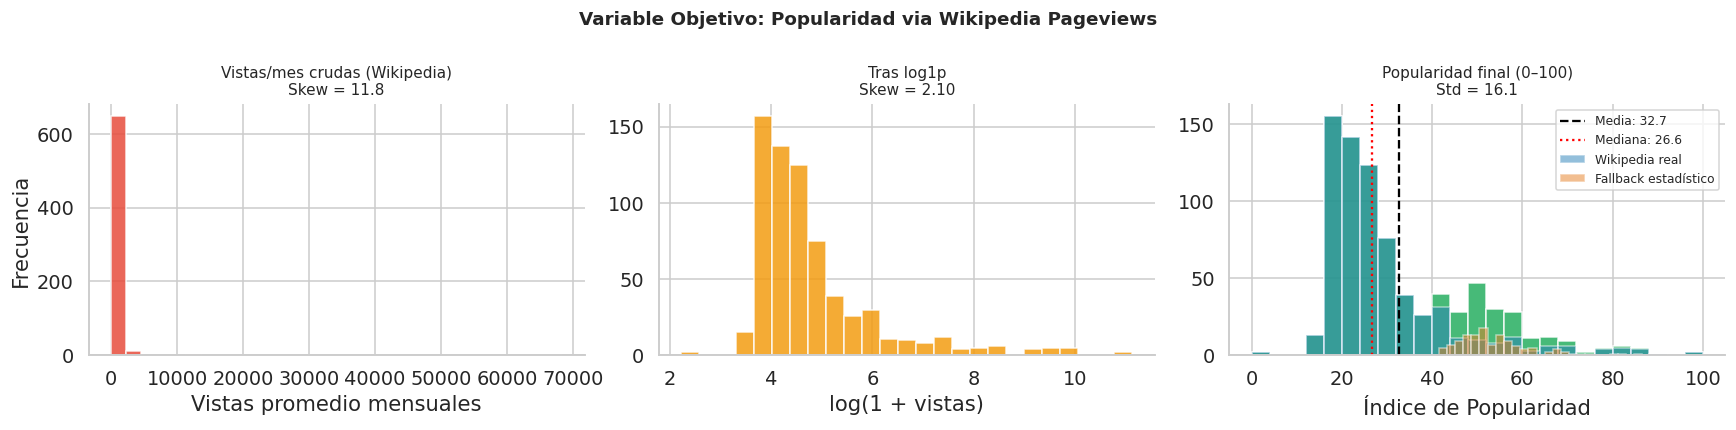

In [10]:
import time
from datetime import datetime, timedelta
from scipy.stats import skew as _skew

WIKI_CACHE       = 'wiki_pageviews.json'
WIKI_BASE_URL    = 'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article'
WIKI_PROJECT     = 'en.wikipedia'
WIKI_ACCESS      = 'all-access'
WIKI_AGENT       = 'all-agents'
WIKI_GRANULARITY = 'monthly'


_hoy    = datetime.now()
_inicio = (_hoy.replace(day=1) - timedelta(days=730)).strftime('%Y%m01')
_fin    = _hoy.replace(day=1).strftime('%Y%m01')
WIKI_START = _inicio
WIKI_END   = _fin

WIKI_HEADERS = {
    'User-Agent': 'ProyectoPokemonDS/1.0 (proyecto-academico; estudiante-data-science)',
    'Accept': 'application/json',
}


TYPE_BONUS = {
    'fire':10, 'dragon':12, 'psychic':8, 'electric':9, 'ghost':8,
    'dark':8,  'fairy':9,  'water':5,  'grass':3,  'normal':2,
    'fighting':5, 'steel':4, 'ice':4, 'rock':2, 'ground':2,
    'bug':1, 'poison':1, 'flying':3,
}



def _nombre_a_articulo_wikipedia(nombre: str) -> list[str]:
    """
    Convierte el nombre de un Pokémon a posibles títulos de artículo en Wikipedia.
    Retorna una lista de candidatos en orden de prioridad.
    """
    nombre = nombre.strip()

    base = nombre.capitalize()

    candidatos = [base]


    especiales = {
        'nidoran♀':  ['Nidoran_(female)', 'Nidoran%E2%99%80'],
        'nidoran♂':  ['Nidoran_(male)',   'Nidoran%E2%99%82'],
        'mr. mime':  ['Mr._Mime'],
        'farfetch\'d':['Farfetch%27d', 'Farfetchd'],
        'ho-oh':     ['Ho-Oh'],
        'mime jr.':  ['Mime_Jr.'],
        'porygon-z': ['Porygon-Z'],
        'type: null':['Type:_Null'],
        'jangmo-o':  ['Jangmo-o'],
        'hakamo-o':  ['Hakamo-o'],
        'kommo-o':   ['Kommo-o'],
        'tapu koko': ['Tapu_Koko'],
        'tapu lele': ['Tapu_Lele'],
        'tapu bulu': ['Tapu_Bulu'],
        'tapu fini': ['Tapu_Fini'],
        'flabébé':   ['Flabébé', 'Flabebe'],
    }

    nombre_lower = nombre.lower()
    if nombre_lower in especiales:
        return especiales[nombre_lower] + candidatos


    if '-' in nombre:
        candidatos.append(nombre.replace('-', '_').capitalize())


    if ' ' in nombre:
        candidatos.append(nombre.replace(' ', '_').capitalize())

    return candidatos


def consultar_pageviews(nombre: str, debug: bool = False) -> dict:
    """
    Consulta la Wikipedia Pageviews API para un Pokémon.
    Retorna dict con 'views_total', 'views_promedio' y 'fuente'.
    Retorna None si no se pudo obtener dato.

    Endpoint:
      GET {BASE}/{project}/{access}/{agent}/{article}/{granularity}/{start}/{end}

    Ejemplo real:
      GET https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/
          en.wikipedia/all-access/all-agents/Pikachu/monthly/20230101/20241201
    """
    candidatos = _nombre_a_articulo_wikipedia(nombre)

    for articulo in candidatos:
        url = (
            f'{WIKI_BASE_URL}/{WIKI_PROJECT}/{WIKI_ACCESS}/{WIKI_AGENT}'
            f'/{articulo}/{WIKI_GRANULARITY}/{WIKI_START}/{WIKI_END}'
        )
        try:
            resp = requests.get(url, headers=WIKI_HEADERS, timeout=10)

            if resp.status_code == 200:
                data   = resp.json()
                items  = data.get('items', [])
                if not items:
                    continue
                vistas = [item['views'] for item in items if 'views' in item]
                if not vistas:
                    continue
                return {
                    'views_total':    sum(vistas),
                    'views_promedio': sum(vistas) / len(vistas),
                    'meses':          len(vistas),
                    'articulo_wiki':  articulo,
                    'fuente':         'wikipedia_api',
                }

            elif resp.status_code == 404:
                if debug:
                    print(f'  [DEBUG] 404 para "{articulo}"')
                continue

            elif resp.status_code == 429:
                print(f'  [AVISO] Rate limit alcanzado. Esperando 30 segundos...')
                time.sleep(30)
                continue

            else:
                if debug:
                    print(f'  [DEBUG] HTTP {resp.status_code} para "{articulo}"')
                continue

        except requests.exceptions.Timeout:
            if debug:
                print(f'  [DEBUG] Timeout para "{nombre}"')
            continue
        except requests.exceptions.ConnectionError as e:
            if debug:
                print(f'  [DEBUG] Error de conexión: {e}')
            continue
        except Exception as e:
            if debug:
                print(f'  [DEBUG] Error inesperado: {e}')
            continue

    return None


def obtener_pageviews_todos(nombres: list[str],
                            cache_path: str = WIKI_CACHE,
                            delay: float = 0.15) -> dict:
    """
    Obtiene pageviews de Wikipedia para una lista de nombres de Pokémon.
    Usa caché local para evitar repetir consultas entre ejecuciones.

    Args:
        nombres:    lista de nombres en minúscula
        cache_path: ruta del archivo JSON de caché
        delay:      segundos entre requests (respetar rate limit de Wikimedia)

    Returns:
        dict nombre → dict con views_total, views_promedio, fuente, etc.
    """
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cache = json.load(f)
        print(f'Caché cargada: {len(cache)} registros existentes')
    else:
        cache = {}


    faltantes = [n for n in nombres if n not in cache]
    print(f'Pokémon a consultar: {len(faltantes)} (ya en caché: {len(cache)})')

    if not faltantes:
        return cache

    errores   = 0
    consultados = 0

    for i, nombre in enumerate(faltantes):
        resultado = consultar_pageviews(nombre)

        if resultado is not None:
            cache[nombre] = resultado
            consultados  += 1
        else:

            cache[nombre] = {'fuente': 'sin_dato', 'views_total': 0,
                             'views_promedio': 0}
            errores += 1


        if (i + 1) % 20 == 0 or i == len(faltantes) - 1:
            with open(cache_path, 'w') as f:
                json.dump(cache, f, indent=2, ensure_ascii=False)
            print(f'  [{i+1}/{len(faltantes)}] Consultados: {consultados} OK | {errores} sin dato')

        time.sleep(delay)

    print(f'\nConsulta finalizada:')
    print(f'  Con dato real de Wikipedia: {consultados}')
    print(f'  Sin dato (irán a fallback):  {errores}')
    return cache




nombres_pokemon = df_raw['name'].str.lower().tolist()
wiki_cache = obtener_pageviews_todos(nombres_pokemon)




n_wikipedia = sum(1 for v in wiki_cache.values() if v.get('fuente') == 'wikipedia_api')
n_sin_dato  = sum(1 for v in wiki_cache.values() if v.get('fuente') == 'sin_dato')

print(f'\nValidación de datos:')
print(f'  Pokémon con dato real de Wikipedia: {n_wikipedia} / {len(nombres_pokemon)}')
print(f'  Pokémon sin dato disponible:         {n_sin_dato}')
print(f'  Cobertura: {n_wikipedia/len(nombres_pokemon)*100:.1f}%')


print(f'\nVerificación de Pokémon icónicos:')
for check in ['pikachu', 'charizard', 'mewtwo', 'eevee', 'gengar', 'lucario']:
    dato = wiki_cache.get(check, {})
    fuente  = dato.get('fuente', 'N/A')
    total   = dato.get('views_total', 0)
    prom    = dato.get('views_promedio', 0)
    print(f'  {check:15s}: {total:>10,.0f} vistas totales | {prom:>8,.0f} prom/mes | [{fuente}]')


if wiki_cache.get('pikachu', {}).get('fuente') != 'wikipedia_api':
    print('\n⚠ ALERTA: Pikachu no tiene dato de Wikipedia — revisar conectividad')
else:
    print('\n✓ Pikachu validado correctamente con dato real de Wikipedia')


def construir_popularidad(nombres: list[str],
                          cache: dict,
                          df_ref) -> tuple[dict, dict]:
    """
    Construye el índice de popularidad (0–100) a partir de los pageviews de Wikipedia.

    Proceso:
    1. Extraer views_promedio por Pokémon
    2. Normalizar con log1p para comprimir la distribución power-law
    3. Min-max al rango 0–100
    4. Para Pokémon sin dato: fallback por tipo/generación/rareza (etiquetado)

    Returns:
        scores:  dict nombre → score 0–100
        fuentes: dict nombre → etiqueta de fuente (trazabilidad)
    """

    vistas_raw = {}
    for nombre in nombres:
        dato = cache.get(nombre, {})
        if dato.get('fuente') == 'wikipedia_api' and dato.get('views_promedio', 0) > 0:
            vistas_raw[nombre] = float(dato['views_promedio'])

    if not vistas_raw:
        print('⚠ Sin datos de Wikipedia disponibles — usando solo proxy estadístico')
        return {}, {}


    import numpy as np
    nombres_con_dato = list(vistas_raw.keys())
    vals = np.array([vistas_raw[n] for n in nombres_con_dato], dtype=float)
    vals_log = np.log1p(vals)


    vmin, vmax = vals_log.min(), vals_log.max()
    if vmax > vmin:
        vals_norm = (vals_log - vmin) / (vmax - vmin) * 100
    else:
        vals_norm = np.full_like(vals_log, 50.0)

    scores  = {n: round(float(v), 1) for n, v in zip(nombres_con_dato, vals_norm)}
    fuentes = {n: 'wikipedia_api' for n in nombres_con_dato}

    return scores, fuentes



wiki_scores, wiki_fuentes = construir_popularidad(nombres_pokemon, wiki_cache, df_raw)

print(f'\nScores de popularidad construidos: {len(wiki_scores)} Pokémon')
if wiki_scores:
    top5 = sorted(wiki_scores.items(), key=lambda x: x[1], reverse=True)[:5]
    print('Top 5 por Wikipedia Pageviews:')
    for nombre, score in top5:
        prom = wiki_cache[nombre].get('views_promedio', 0)
        print(f'  {nombre:15s}: score={score:.1f} | {prom:,.0f} vistas/mes')




stat_cols_raw = [c for c in ['hp','attack','defense','sp_attack','sp_defense','speed']
                 if c in df_raw.columns]
df_raw['total_stats'] = df_raw[stat_cols_raw].sum(axis=1)

np.random.seed(2024)

def asignar_popularidad(row, scores_dict, fuentes_dict, df_ref):
    """
    Asigna un score de popularidad a un Pokémon.
    Fuente 1 (prioritaria): Wikipedia Pageviews normalizado.
    Fuente 2 (fallback etiquetado): estimación por tipo/gen/rareza.
    NUNCA mezcla silenciosamente ambas fuentes — todo queda en popularity_source.
    """
    nombre = str(row['name']).lower()


    if nombre in scores_dict:
        score = scores_dict[nombre]
        if not np.isnan(score):
            return score, 'wikipedia_api'


    gen_b  = {1:14, 2:8, 3:6, 4:6, 5:4, 6:5, 7:5, 8:4}.get(int(row.get('generation', 1)), 3)
    leg_b  = 18 if bool(row.get('is_legendary', False)) else 0
    typ_b  = TYPE_BONUS.get(str(row.get('type1', '')).lower(), 2)
    stat_b = min(float(row.get('total_stats', 300)) / 7.5, 13)
    score_proxy = float(np.clip(
        28 + gen_b + leg_b + typ_b + stat_b + np.random.normal(0, 4), 5, 95
    ))
    return score_proxy, 'fallback_estadistico'



resultados_pop = df_raw.apply(
    lambda row: asignar_popularidad(row, wiki_scores, wiki_fuentes, df_raw),
    axis=1
)

df_raw['popularity']        = [r[0] for r in resultados_pop]
df_raw['popularity_source']  = [r[1] for r in resultados_pop]


fuentes_resumen = df_raw['popularity_source'].value_counts()
print(f'\nResumen de fuentes de popularidad:')
for fuente, n in fuentes_resumen.items():
    print(f'  {fuente}: {n} Pokémon')

print(f'\nEstadísticas de popularity:')
print(f'  Rango:  [{df_raw["popularity"].min():.1f}, {df_raw["popularity"].max():.1f}]')
print(f'  Media:  {df_raw["popularity"].mean():.1f}')
print(f'  Std:    {df_raw["popularity"].std():.1f}')
print(f'  NaN:    {df_raw["popularity"].isna().sum()}')




wiki_vals = df_raw[df_raw['popularity_source'] == 'wikipedia_api']['popularity']
fallback_vals = df_raw[df_raw['popularity_source'] == 'fallback_estadistico']['popularity']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Variable Objetivo: Popularidad via Wikipedia Pageviews',
             fontsize=12, fontweight='bold')


nombres_con_wiki = [n for n in nombres_pokemon if wiki_cache.get(n, {}).get('fuente') == 'wikipedia_api']
vistas_crudas = np.array([wiki_cache[n]['views_promedio'] for n in nombres_con_wiki])
axes[0].hist(vistas_crudas, bins=30, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Vistas/mes crudas (Wikipedia)\nSkew = {_skew(vistas_crudas):.1f}', fontsize=10)
axes[0].set_xlabel('Vistas promedio mensuales')
axes[0].set_ylabel('Frecuencia')


vistas_log = np.log1p(vistas_crudas)
axes[1].hist(vistas_log, bins=25, color='#F39C12', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Tras log1p\nSkew = {_skew(vistas_log):.2f}', fontsize=10)
axes[1].set_xlabel('log(1 + vistas)')


axes[2].hist(df_raw['popularity'], bins=25, color='#27AE60', edgecolor='white', alpha=0.85)
axes[2].axvline(df_raw['popularity'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Media: {df_raw['popularity'].mean():.1f}")
axes[2].axvline(df_raw['popularity'].median(), color='red', linestyle=':', linewidth=1.5,
                label=f"Mediana: {df_raw['popularity'].median():.1f}")

axes[2].hist(wiki_vals, bins=25, color='#2980B9', alpha=0.5, label='Wikipedia real')
axes[2].hist(fallback_vals, bins=25, color='#E67E22', alpha=0.5, label='Fallback estadístico')
axes[2].set_title(f'Popularidad final (0–100)\nStd = {df_raw["popularity"].std():.1f}',
                  fontsize=10)
axes[2].set_xlabel('Índice de Popularidad')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 6.4 Integración de todas las fuentes

In [11]:
df_raw['name_key'] = df_raw['name'].str.lower()
df_api = df_api.rename(columns={'name': 'name_key'})

df = df_raw.merge(df_api, on='name_key', how='left')
df.drop(columns=['name_key'], inplace=True)

df.to_csv('pokemon_consolidado.csv', index=False)
print(f"DataFrame consolidado: {df.shape[0]} filas × {df.shape[1]} columnas")
print("Guardado en 'pokemon_consolidado.csv'")
df.info()


DataFrame consolidado: 801 filas × 47 columnas
Guardado en 'pokemon_consolidado.csv'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    fl

---
## 7. Limpieza y Transformación de Datos

Aplicamos las etapas estándar: análisis de nulos, tratamiento de duplicados, imputación de valores faltantes y creación de nuevas variables derivadas.


#### 7.1 PORCENTAJE DE NULOS

              REPORTE DE CALIDAD DE DATOS              
  Filas totales:    801
  Columnas totales: 47
  Duplicados:       0

  VALORES NULOS:
                 nulos  % del total
type2              384         47.9
percentage_male     98         12.2
n_abilities         31          3.9
base_experience     31          3.9
n_moves             31          3.9
height_m            20          2.5
weight_kg           20          2.5



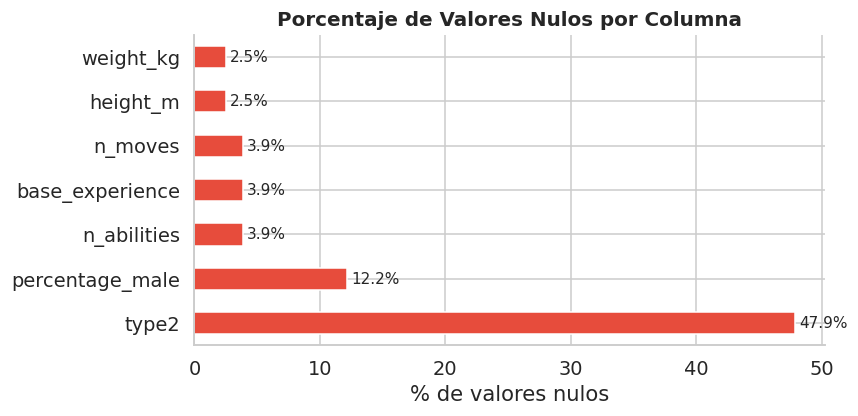

In [12]:
print(" REPORTE DE CALIDAD DE DATOS ".center(55))
print(f"  Filas totales:    {df.shape[0]}")
print(f"  Columnas totales: {df.shape[1]}")
print(f"  Duplicados:       {df.duplicated().sum()}")
print("")

nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
null_report = pd.DataFrame({'nulos': nulls, '% del total': nulls_pct})
null_report = null_report[null_report['nulos'] > 0].sort_values('nulos', ascending=False)

if len(null_report) > 0:
    print("  VALORES NULOS:")
    print(null_report.to_string())
    print()
    fig, ax = plt.subplots(figsize=(8, 4))
    null_report['% del total'].plot(kind='barh', ax=ax, color='#E74C3C', edgecolor='white')
    ax.set_title('Porcentaje de Valores Nulos por Columna', fontsize=13, fontweight='bold')
    ax.set_xlabel('% de valores nulos')
    for p in ax.patches:
        ax.text(p.get_width() + 0.3, p.get_y() + p.get_height()/2,
                f'{p.get_width():.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("  No hay valores nulos en las columnas numéricas clave.")


####  7.2 LIMPIEZA DE NULOS

In [13]:
df['type2'] = df['type2'].fillna('none')
print("type2: nulos → 'none'")


for col in ['n_abilities', 'n_moves', 'base_experience']:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"'{col}': imputado con mediana ({median_val:.0f})")

n_dups = df.duplicated(subset=['name']).sum()
if n_dups > 0:
    df = df.drop_duplicates(subset=['name'])
    print(f"\n{n_dups} duplicados eliminados")
else:
    print("\nSin duplicados")

print(f"\nDataset limpio: {df.shape}")


type2: nulos → 'none'
'n_abilities': imputado con mediana (3)
'n_moves': imputado con mediana (83)
'base_experience': imputado con mediana (149)

Sin duplicados

Dataset limpio: (801, 47)


#### 7.3 CREACION DE FEATURES

In [14]:
# Ratio ofensivo/defensivo
df['attack_defense_ratio'] = (df['attack'] / (df['defense'] + 1)).round(3)

# Ratio especial vs físico
df['special_physical_ratio'] = (df['sp_attack'] / (df['attack'] + 1)).round(3)

# Tiene tipo secundario
df['has_secondary_type'] = (df['type2'] != 'none').astype(int)

# Tipo "visualmente impactante" — los que históricamente concentran más interés
POWER_TYPES = {'fire','dragon','psychic','electric','ghost','dark','fairy'}
df['is_power_type'] = df['type1'].isin(POWER_TYPES).astype(int)

# Índice ofensivo compuesto
df['combat_score'] = ((df['attack'] + df['sp_attack'] + df['speed']) / 3).round(1)

# Efecto nostalgia: mayor valor = generación más antigua
df['nostalgia_score'] = df['generation'].max() - df['generation'] + 1

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type1_enc'] = le.fit_transform(df['type1'].astype(str))
df['is_legendary_int'] = df['is_legendary'].astype(int)

print("Features de ingeniería creadas:")
new_feats = ['attack_defense_ratio','special_physical_ratio',
             'has_secondary_type','is_power_type','combat_score','nostalgia_score']
df[new_feats].describe().round(2)


Features de ingeniería creadas:


,attack_defense_ratio,special_physical_ratio,has_secondary_type,is_power_type,combat_score,nostalgia_score
count,801.00,801.00,801.00,801.00,801.00,801.00
mean,1.13,1.02,0.52,0.31,71.83,4.31
std,0.46,0.59,0.50,0.46,23.94,1.93
min,0.04,0.10,0.00,0.00,8.30,1.00
25%,0.82,0.64,0.00,0.00,54.00,3.00
50%,1.05,0.97,1.00,0.00,70.00,4.00
75%,1.39,1.23,1.00,1.00,86.70,6.00
max,4.29,6.82,1.00,1.00,161.30,7.00


---
## 8. Análisis Exploratorio de Datos (EDA)

El EDA está organizado en bloques temáticos, cada uno orientado a responder una de las hipótesis planteadas. Primero miramos la distribución general de las variables y después profundizamos en cada relación.


#### 8.1 ESTADISTISCAS DESCRIPTIVAS

In [15]:
stats_cols = ['popularity','total_stats','hp','attack','defense','sp_attack','sp_defense','speed']
stats_cols = [c for c in stats_cols if c in df.columns]
df[stats_cols].describe().round(1)


,popularity,total_stats,hp,attack,defense,sp_attack,sp_defense,speed
count,801.0,801.0,801.0,801.0,801.0,801.0,801.0,801.0
mean,32.7,428.4,69.0,77.9,73.0,71.3,70.9,66.3
std,16.1,119.2,26.6,32.2,30.8,32.4,27.9,28.9
min,0.0,180.0,1.0,5.0,5.0,10.0,20.0,5.0
25%,20.7,320.0,50.0,55.0,50.0,45.0,50.0,45.0
50%,26.6,435.0,65.0,75.0,70.0,65.0,66.0,65.0
75%,42.6,505.0,80.0,100.0,90.0,91.0,90.0,85.0
max,100.0,780.0,255.0,185.0,230.0,194.0,230.0,180.0


#### 8.2 DISTRIBUCIÓN DE POPULARIDAD Y STATS PRINCIPALES

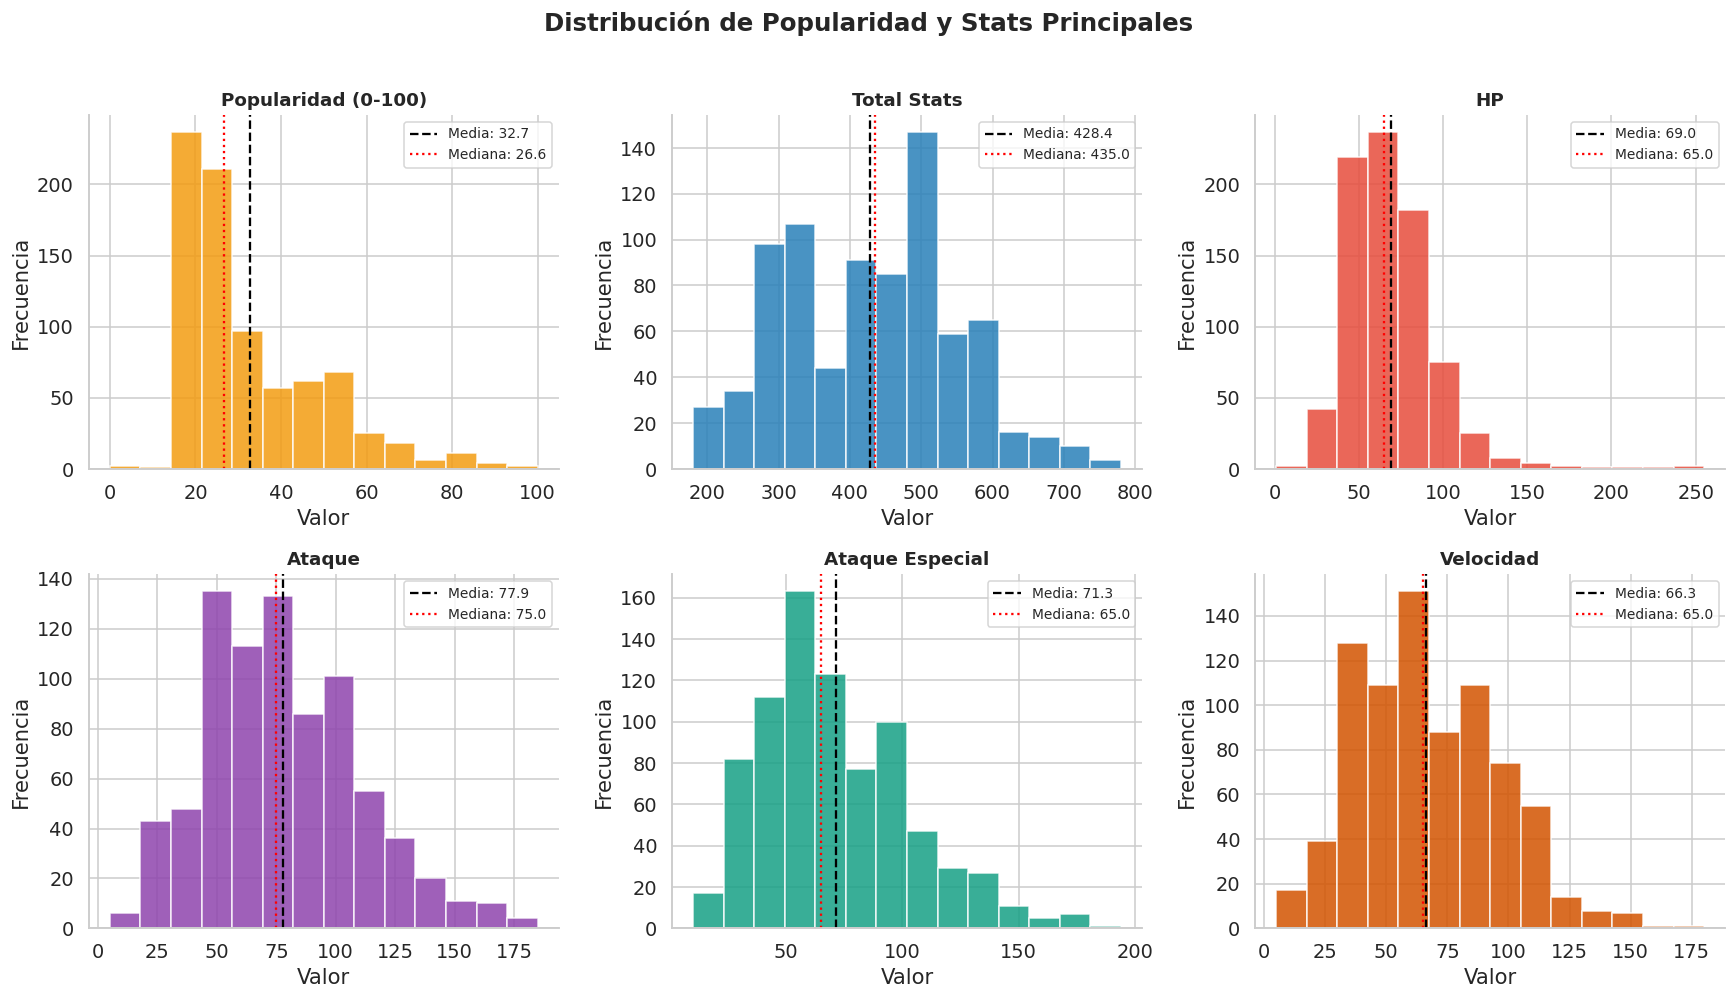


📐 Asimetría (skewness) de Popularidad: 1.252
   → Distribución sesgada a la derecha (mayoría de Pokémon tienen popularidad baja/media)


In [16]:



fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Popularidad y Stats Principales',
             fontsize=16, fontweight='bold', y=1.01)

plot_data = [
    ('popularity',  'Popularidad (0-100)', '#F39C12'),
    ('total_stats', 'Total Stats',         '#2980B9'),
    ('hp',          'HP',                  '#E74C3C'),
    ('attack',      'Ataque',               '#8E44AD'),
    ('sp_attack',   'Ataque Especial',       '#16A085'),
    ('speed',       'Velocidad',             '#D35400'),
]

for ax, (col, label, color) in zip(axes.flatten(), plot_data):
    if col not in df.columns:
        continue
    data = df[col].dropna()
    ax.hist(data, bins=14, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5,
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


pop_skew = stats.skew(df['popularity'])
print(f"\n📐 Asimetría (skewness) de Popularidad: {pop_skew:.3f}")
if abs(pop_skew) < 0.5:
    print("   → Distribución aproximadamente simétrica")
elif pop_skew > 0:
    print("   → Distribución sesgada a la derecha (mayoría de Pokémon tienen popularidad baja/media)")
else:
    print("   → Distribución sesgada a la izquierda")

#### 8.3 HIPOTESIS 1

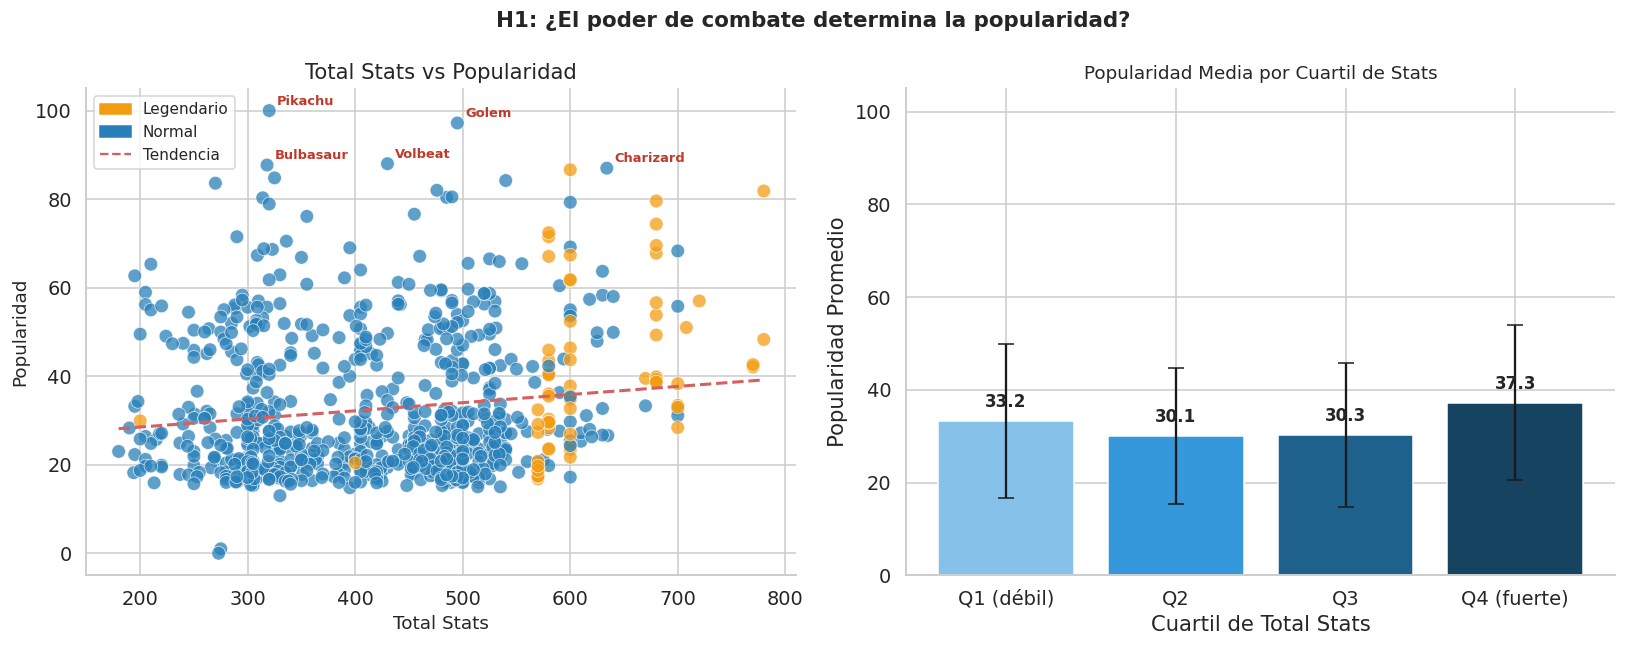

Correlación de Pearson (Total Stats ↔ Popularidad): r = 0.136
H1 parcialmente confirmada: el poder tiene influencia positiva pero débil.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('H1: ¿El poder de combate determina la popularidad?', fontsize=14, fontweight='bold')

ax = axes[0]
colors_scatter = df['is_legendary'].map({1: '#F39C12', 0: '#2980B9'})
ax.scatter(df['total_stats'], df['popularity'],
           c=colors_scatter, s=80, alpha=0.75, edgecolors='white', linewidth=0.5)

valid = df[['total_stats','popularity']].dropna()
z = np.polyfit(valid['total_stats'], valid['popularity'], 1)
p_fn = np.poly1d(z)
x_line = np.linspace(valid['total_stats'].min(), valid['total_stats'].max(), 100)
ax.plot(x_line, p_fn(x_line), 'r--', linewidth=2, label='Tendencia lineal')

for _, row in df.nlargest(5, 'popularity').iterrows():
    ax.annotate(row['name'], (row['total_stats'], row['popularity']),
                fontsize=8.5, xytext=(5, 4), textcoords='offset points',
                color='#C0392B', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#F39C12', label='Legendario'),
    mpatches.Patch(color='#2980B9', label='Normal')
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='r', linestyle='--', label='Tendencia')], fontsize=10)
ax.set_xlabel('Total Stats', fontsize=12)
ax.set_ylabel('Popularidad', fontsize=12)
ax.set_title('Total Stats vs Popularidad')

ax2 = axes[1]
df['stats_quartile'] = pd.qcut(df['total_stats'], q=4, labels=['Q1 (débil)','Q2','Q3','Q4 (fuerte)'])
q_means = df.groupby('stats_quartile', observed=True)['popularity'].mean()
q_std   = df.groupby('stats_quartile', observed=True)['popularity'].std()

bars = ax2.bar(q_means.index, q_means.values, color=['#85C1E9','#3498DB','#1F618D','#154360'],
               edgecolor='white', yerr=q_std.values, capsize=5)
ax2.set_title('Popularidad Media por Cuartil de Stats', fontsize=12)
ax2.set_xlabel('Cuartil de Total Stats')
ax2.set_ylabel('Popularidad Promedio')
ax2.set_ylim(0, 105)
for bar, val in zip(bars, q_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 3,
             f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

corr_h1 = df[['total_stats','popularity']].corr().iloc[0,1]
print(f"Correlación de Pearson (Total Stats ↔ Popularidad): r = {corr_h1:.3f}")
print("H1 parcialmente confirmada: el poder tiene influencia positiva pero débil.")


#### 8.4 HIPOTESIS 2

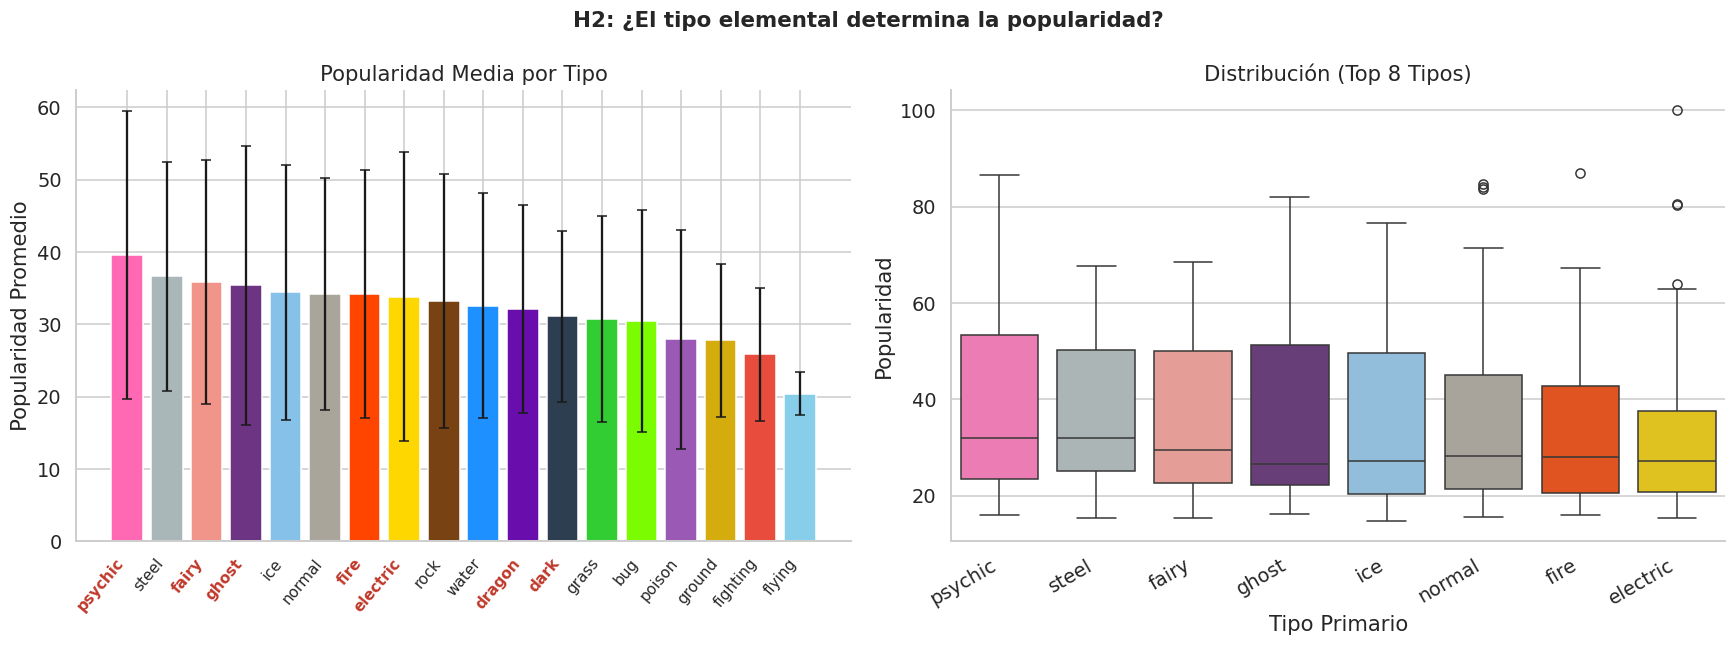


Top 3 tipos más populares: ['psychic', 'steel', 'fairy']
   H2 CONFIRMADA: Tipos como Fuego/Dragón/Psíquico dominan el ranking.


In [18]:
TYPE_COLORS = {
    'fire':'#FF4500','water':'#1E90FF','grass':'#32CD32','electric':'#FFD700',
    'psychic':'#FF69B4','dragon':'#6A0DAD','normal':'#AAA59A','poison':'#9B59B6',
    'bug':'#7CFC00','ghost':'#6C3483','dark':'#2C3E50','steel':'#AAB7B8',
    'fighting':'#E74C3C','rock':'#784212','ground':'#D4AC0D','ice':'#85C1E9',
    'fairy':'#F1948A','flying':'#87CEEB'
}

type_stats = df.groupby('type1')['popularity'].agg(['mean','median','count','std'])
type_stats = type_stats.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('H2: ¿El tipo elemental determina la popularidad?',
             fontsize=14, fontweight='bold')


ax = axes[0]
bar_colors = [TYPE_COLORS.get(t, '#888') for t in type_stats.index]
bars = ax.bar(range(len(type_stats)), type_stats['mean'].values,
              color=bar_colors, edgecolor='white',
              yerr=type_stats['std'].values, capsize=3)
ax.set_xticks(range(len(type_stats)))
ax.set_xticklabels(type_stats.index, rotation=50, ha='right', fontsize=10)
ax.set_title('Popularidad Media por Tipo')
ax.set_ylabel('Popularidad Promedio')

for i, tipo in enumerate(type_stats.index):
    if tipo in POWER_TYPES:
        ax.get_xticklabels()[i].set_fontweight('bold')
        ax.get_xticklabels()[i].set_color('#C0392B')


ax2 = axes[1]
top_types = type_stats.head(8).index.tolist()
df_top = df[df['type1'].isin(top_types)].copy()
type_order = type_stats.head(8).index.tolist()
palette_top = [TYPE_COLORS.get(t,'#888') for t in type_order]
sns.boxplot(data=df_top, x='type1', y='popularity',
            order=type_order, palette=palette_top, ax=ax2)
ax2.set_xticklabels(type_order, rotation=30, ha='right')
ax2.set_title('Distribución (Top 8 Tipos)')
ax2.set_xlabel('Tipo Primario')
ax2.set_ylabel('Popularidad')

plt.tight_layout()
plt.show()


top3_types = type_stats.head(3).index.tolist()
h2_confirmed = any(t in POWER_TYPES for t in top3_types)
print(f"\nTop 3 tipos más populares: {top3_types}")
print(f"   {'H2 CONFIRMADA' if h2_confirmed else 'H2  PARCIAL'}: Tipos como Fuego/Dragón/Psíquico dominan el ranking.")

#### 8.4 HIPOTESIS 3

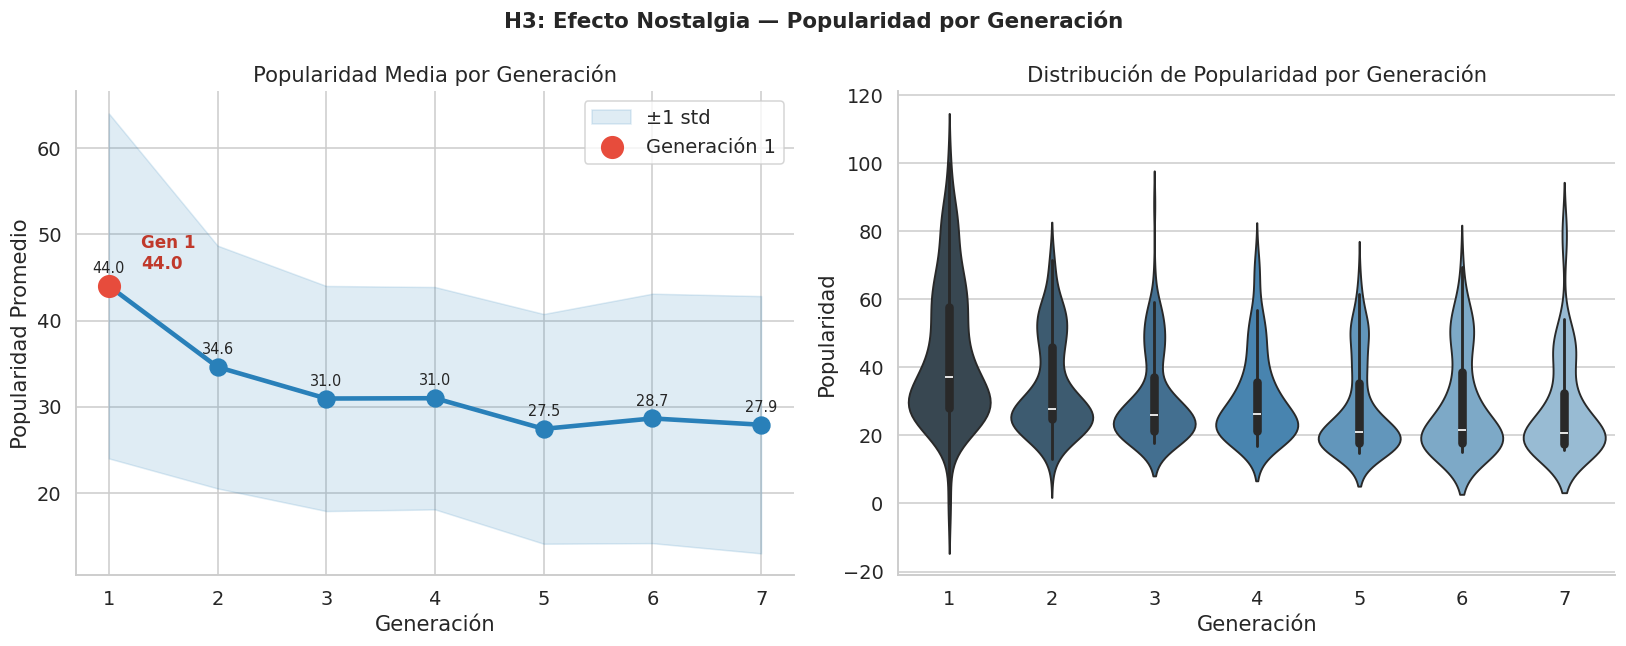


 Correlación Generación ↔ Popularidad: r = -0.315 (p = 0.000)
Gen 1 ocupa el puesto #1 en popularidad
H3 CONFIRMADA: Existe correlación negativa entre generación y popularidad.
→ Pokémon más antiguos tienden a ser más populares (efecto nostalgia).


In [19]:



gen_agg = df.groupby('generation')['popularity'].agg(['mean','std','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('H3: Efecto Nostalgia — Popularidad por Generación',
             fontsize=14, fontweight='bold')


ax = axes[0]
gen_mean = df.groupby('generation')['popularity'].mean()
gen_std  = df.groupby('generation')['popularity'].std()
gens = gen_mean.index.tolist()

ax.plot(gens, gen_mean.values, marker='o', linewidth=3,
        markersize=11, color='#2980B9', zorder=5)
ax.fill_between(gens,
                gen_mean.values - gen_std.values,
                gen_mean.values + gen_std.values,
                alpha=0.15, color='#2980B9', label='±1 std')


ax.scatter([1], [gen_mean[1]], color='#E74C3C', s=200, zorder=6, label='Generación 1')
ax.annotate(f"Gen 1\n{gen_mean[1]:.1f}", xy=(1, gen_mean[1]),
            xytext=(1.3, gen_mean[1]+2), fontsize=11, color='#C0392B', fontweight='bold')

for gen, val in zip(gens, gen_mean.values):
    ax.text(gen, val + 1.5, f'{val:.1f}', ha='center', fontsize=9.5)

ax.set_xticks(gens)
ax.set_title('Popularidad Media por Generación')
ax.set_xlabel('Generación')
ax.set_ylabel('Popularidad Promedio')
ax.legend()


ax2 = axes[1]
gen_palette = sns.color_palette('Blues_d', len(gens))[::-1]
sns.violinplot(data=df, x='generation', y='popularity',
               order=gens, palette=gen_palette, ax=ax2, inner='box')
ax2.set_title('Distribución de Popularidad por Generación')
ax2.set_xlabel('Generación')
ax2.set_ylabel('Popularidad')

plt.tight_layout()
plt.show()


corr_h3, p_h3 = stats.pearsonr(df['generation'], df['popularity'])
gen1_rank = gen_mean.rank(ascending=False)[1]
print(f"\n Correlación Generación ↔ Popularidad: r = {corr_h3:.3f} (p = {p_h3:.3f})")
print(f"Gen 1 ocupa el puesto #{int(gen1_rank)} en popularidad")
print(f"{'H3 CONFIRMADA' if corr_h3 < -0.1 else 'H3  PARCIAL'}: Existe correlación negativa entre generación y popularidad.")
print("→ Pokémon más antiguos tienden a ser más populares (efecto nostalgia).")

#### 8.5 HIPOTESIS 4

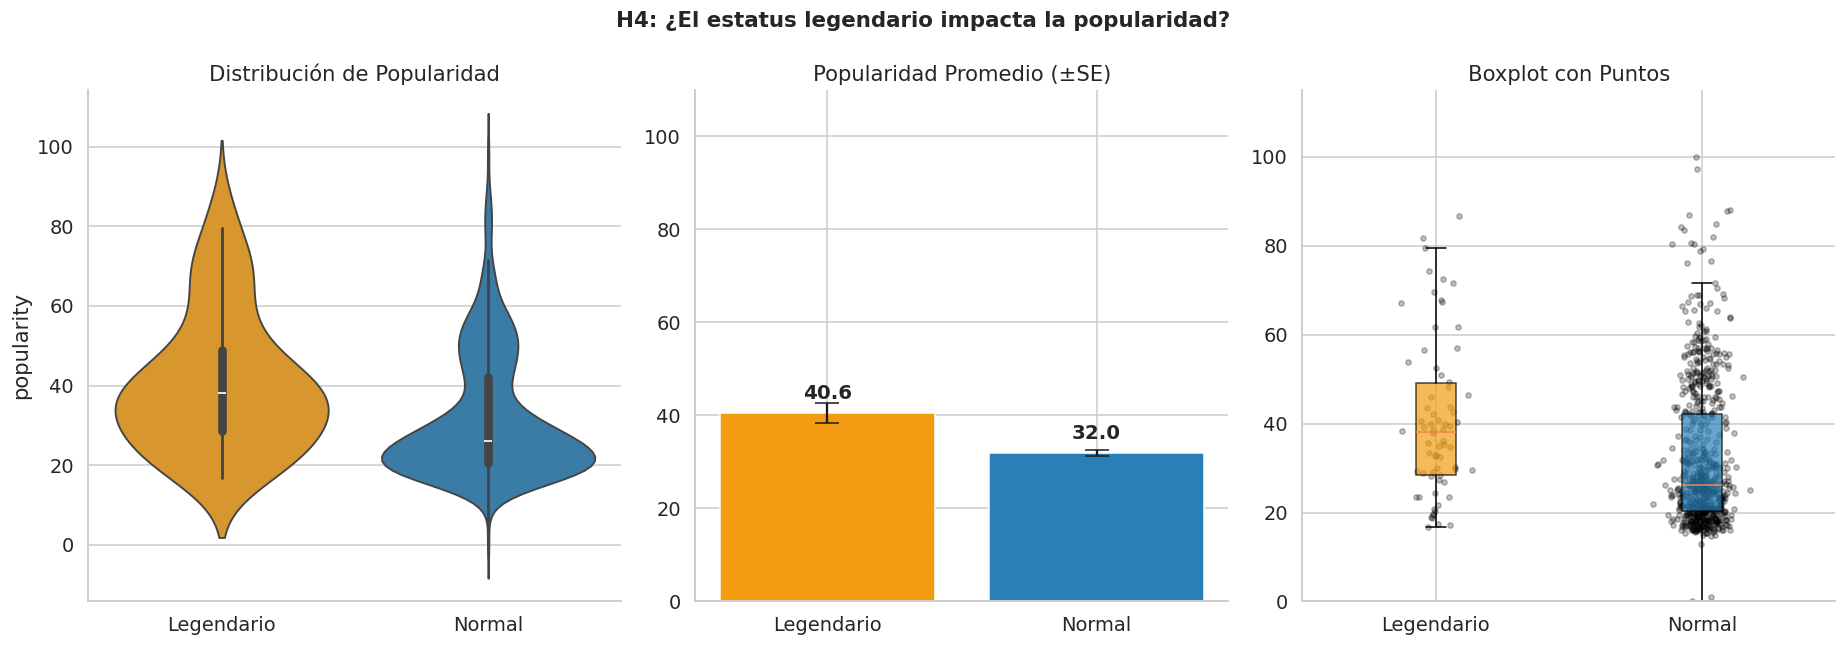

Test Mann-Whitney U (Legendario > Normal):
  U = 34050.0 | p-valor = 0.0000
  Diferencia de medias = 8.6 puntos
  H4 CONFIRMADA — diferencia estadísticamente significativa


In [20]:



fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('H4: ¿El estatus legendario impacta la popularidad?',
             fontsize=14, fontweight='bold')

df['Estatus'] = df['is_legendary'].map({1: 'Legendario', 0: 'Normal'})

leg_data  = df[df['is_legendary'] == 1]['popularity']
norm_data = df[df['is_legendary'] == 0]['popularity']


sns.violinplot(
    data=df, x='Estatus', y='popularity',
    order=['Legendario', 'Normal'],
    palette={'Legendario': '#F39C12', 'Normal': '#2980B9'},
    inner='box', ax=axes[0]
)
axes[0].set_title('Distribución de Popularidad')
axes[0].set_xlabel('')


means  = [leg_data.mean(), norm_data.mean()]
sems   = [leg_data.sem(),  norm_data.sem()]
labels = ['Legendario', 'Normal']

axes[1].bar(labels, means, yerr=sems, capsize=8,
            color=['#F39C12', '#2980B9'], edgecolor='white')
axes[1].set_title('Popularidad Promedio (±SE)')
axes[1].set_ylim(0, 110)
for i, val in enumerate(means):
    axes[1].text(i, val + 3, f'{val:.1f}', ha='center', fontweight='bold', fontsize=13)


box = axes[2].boxplot([leg_data, norm_data], patch_artist=True,
                      labels=['Legendario', 'Normal'], showfliers=False)
for patch, color in zip(box['boxes'], ['#F39C12', '#2980B9']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate([leg_data, norm_data], start=1):
    axes[2].scatter(np.random.normal(i, 0.05, size=len(data)), data,
                    alpha=0.25, color='black', s=12)

axes[2].set_title('Boxplot con Puntos')
axes[2].set_ylim(0, 115)

plt.tight_layout()
plt.show()

stat_mw, p_mw = stats.mannwhitneyu(leg_data, norm_data, alternative='greater')
h4_confirmed  = p_mw < 0.05

print(f'Test Mann-Whitney U (Legendario > Normal):')
print(f'  U = {stat_mw:.1f} | p-valor = {p_mw:.4f}')
print(f'  Diferencia de medias = {leg_data.mean() - norm_data.mean():.1f} puntos')
print(f"  H4 {'CONFIRMADA' if h4_confirmed else 'RECHAZADA'} — "
      f"{'diferencia estadísticamente significativa' if h4_confirmed else 'sin diferencia significativa'}")


#### 8.6 HEATMAP DE CORRELACIONES

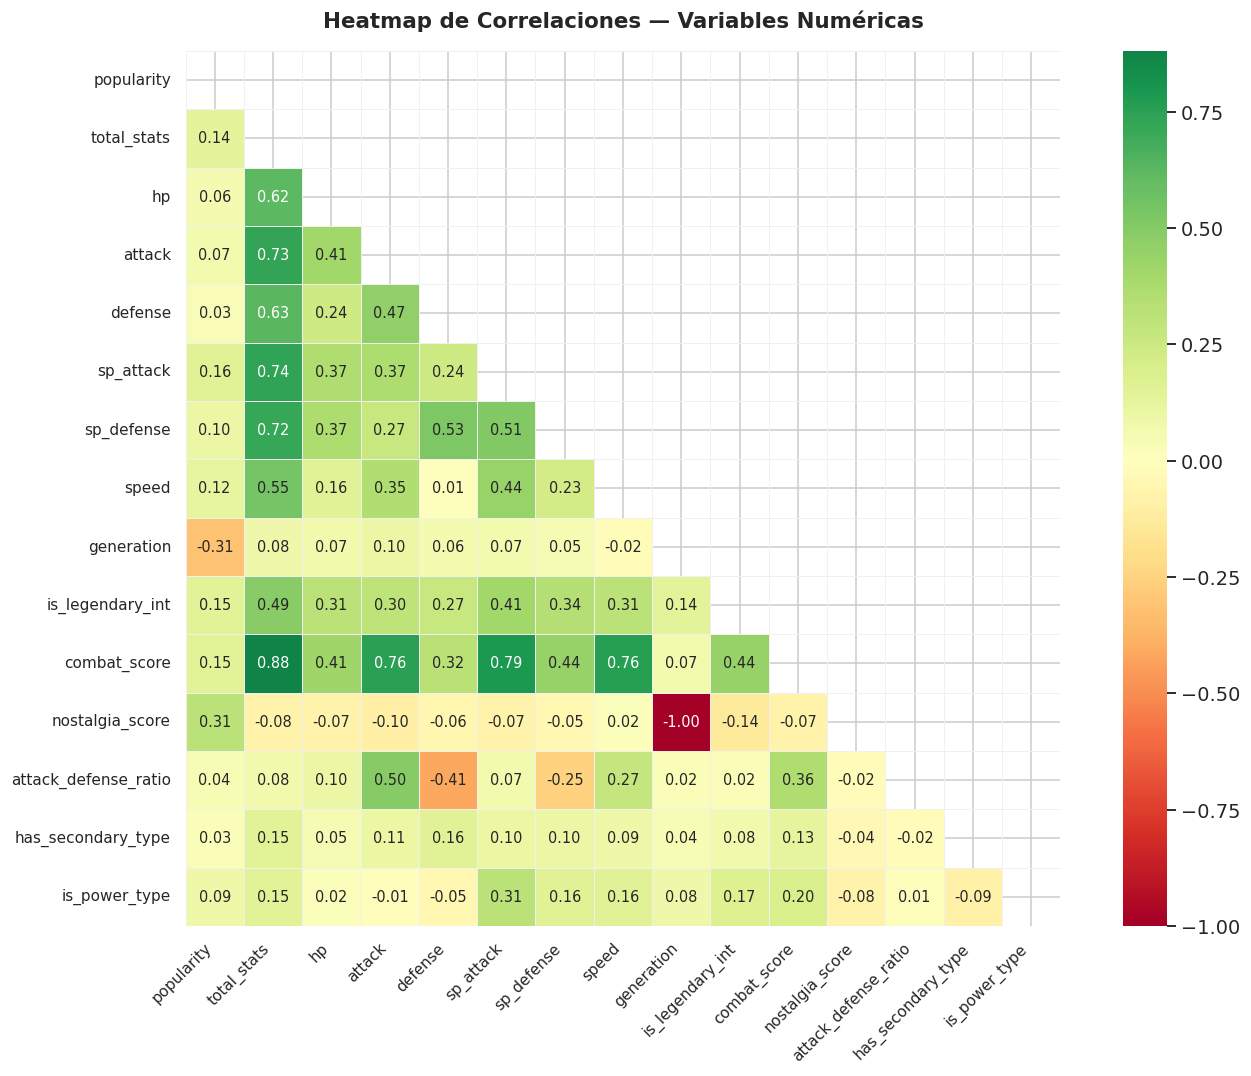


 Variables con mayor correlación con 'popularidad':
generation         -0.315
nostalgia_score     0.315
sp_attack           0.158
is_legendary_int    0.151
combat_score        0.151
total_stats         0.136
speed               0.118
sp_defense          0.102


In [21]:



corr_cols = ['popularity','total_stats','hp','attack','defense',
             'sp_attack','sp_defense','speed',
             'generation','is_legendary_int',
             'combat_score','nostalgia_score',
             'attack_defense_ratio','has_secondary_type','is_power_type']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.4, linecolor='#f0f0f0',
    ax=ax, annot_kws={'size': 9.5}
)
ax.set_title('Heatmap de Correlaciones — Variables Numéricas',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


corr_pop = corr_matrix['popularity'].drop('popularity').sort_values(key=abs, ascending=False)
print("\n Variables con mayor correlación con 'popularidad':")
print(corr_pop.round(3).head(8).to_string())

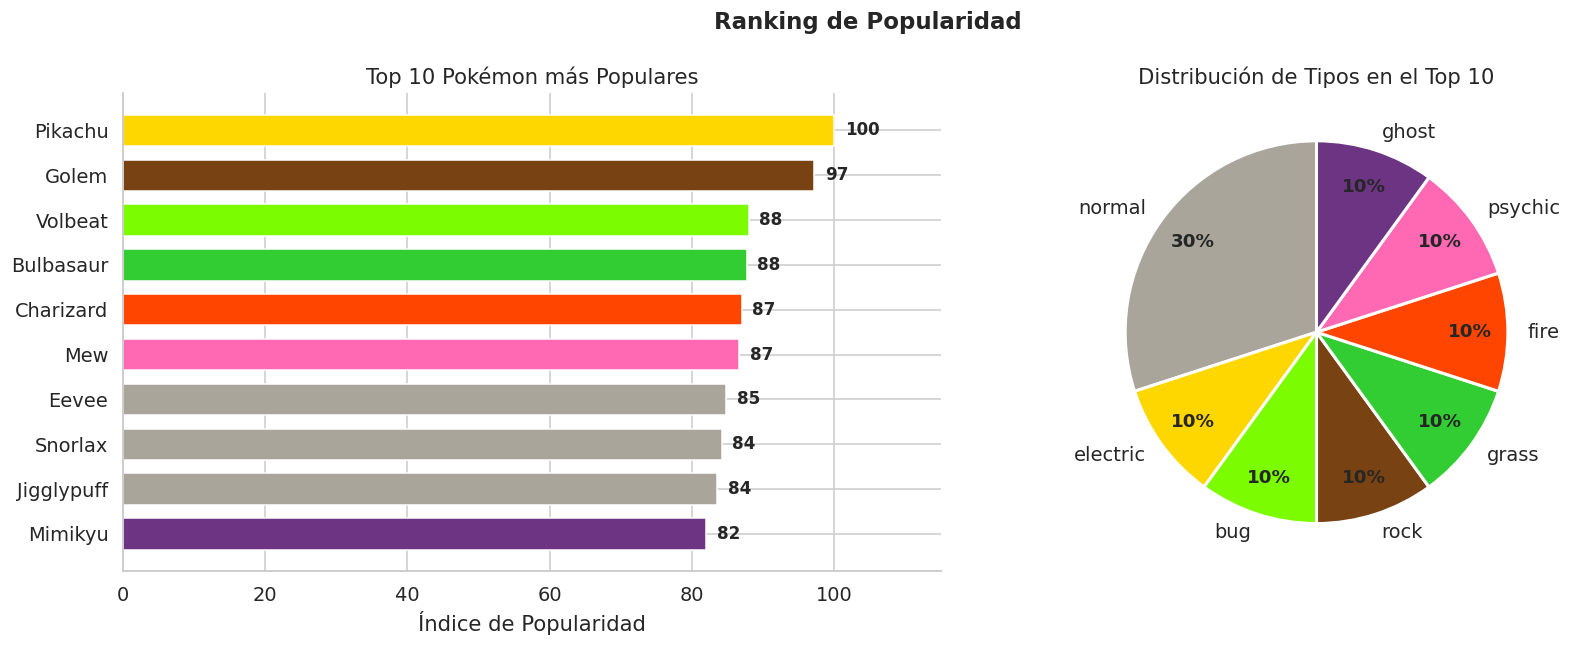


Top 10 completo:
          name  popularity     type1  generation  is_legendary
1      Pikachu  100.000000  electric           1             0
2        Golem   97.200000      rock           1             0
3      Volbeat   88.000000       bug           3             0
4    Bulbasaur   87.700000     grass           1             0
5    Charizard   87.000000      fire           1             0
6          Mew   86.634892   psychic           1             1
7        Eevee   84.800000    normal           1             0
8      Snorlax   84.200000    normal           1             0
9   Jigglypuff   83.600000    normal           1             0
10     Mimikyu   82.000000     ghost           7             0


In [22]:
top10 = df.nlargest(10, 'popularity')[['name','popularity','type1','generation','is_legendary']].reset_index(drop=True)
top10.index += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ranking de Popularidad', fontsize=15, fontweight='bold')

ax = axes[0]
colors_top = [TYPE_COLORS.get(t, '#888') for t in top10['type1']]
bars = ax.barh(top10['name'], top10['popularity'], color=colors_top, edgecolor='white', height=0.7)
ax.invert_yaxis()
ax.set_xlabel('Índice de Popularidad')
ax.set_title('Top 10 Pokémon más Populares')
ax.set_xlim(0, 115)
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f"{row['popularity']:.0f}",
            va='center', fontsize=11, fontweight='bold')

ax2 = axes[1]
type_counts_top = top10['type1'].value_counts()
pie_colors = [TYPE_COLORS.get(t, '#888') for t in type_counts_top.index]
wedges, texts, autotexts = ax2.pie(
    type_counts_top.values,
    labels=type_counts_top.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    pctdistance=0.8,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
ax2.set_title('Distribución de Tipos en el Top 10')

plt.tight_layout()
plt.show()

print('\nTop 10 completo:')
print(top10.to_string())


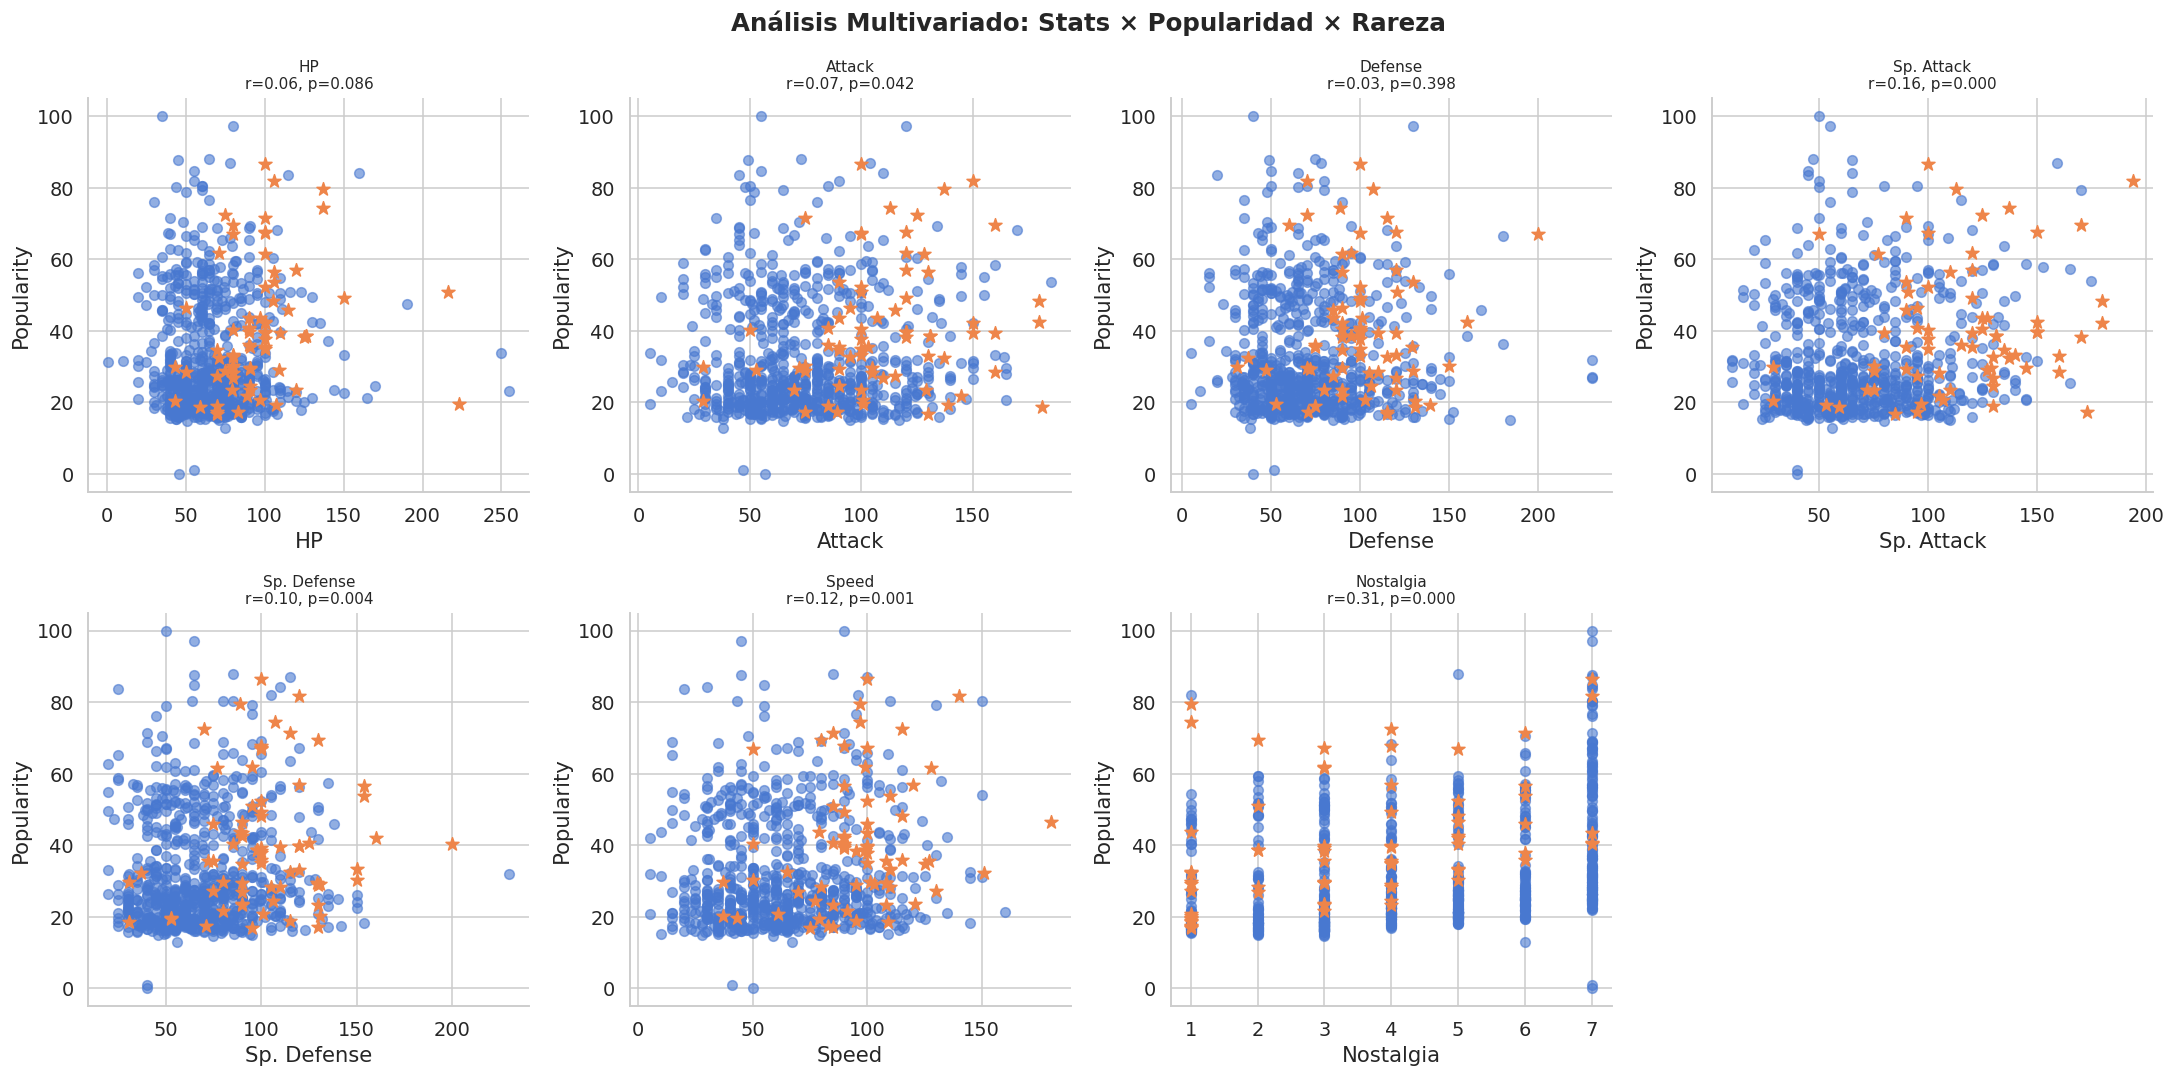

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

fig.suptitle(
    'Análisis Multivariado: Stats × Popularidad × Rareza',
    fontsize=16,
    fontweight='bold'
)

scatter_pairs = [
    ('hp', 'HP'),
    ('attack', 'Attack'),
    ('defense', 'Defense'),
    ('sp_attack', 'Sp. Attack'),
    ('sp_defense', 'Sp. Defense'),
    ('speed', 'Speed'),
    ('nostalgia_score', 'Nostalgia'),
]

for i, (xvar, xlabel) in enumerate(scatter_pairs):

    ax = axes[i]

    if xvar not in df.columns:
        ax.set_visible(False)
        continue

    leg_mask = df['is_legendary'] == 1

    ax.scatter(
        df.loc[~leg_mask, xvar],
        df.loc[~leg_mask, 'popularity'],
        alpha=0.6,
        s=40,
        label='Normal'
    )

    ax.scatter(
        df.loc[leg_mask, xvar],
        df.loc[leg_mask, 'popularity'],
        s=80,
        marker='*',
        label='Legendary'
    )

    sub = df[[xvar, 'popularity']].dropna()
    if len(sub) > 2:
        r, p = stats.pearsonr(sub[xvar], sub['popularity'])
        ax.set_title(f"{xlabel}\nr={r:.2f}, p={p:.3f}", fontsize=10)
    else:
        ax.set_title(xlabel)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Popularity')


for j in range(len(scatter_pairs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. Conclusiones del EDA

El análisis exploratorio sobre los 801 Pokémon del dataset arrojó resultados interesantes, algunos esperados y otros sorprendentes. A continuación resumo qué pasó con cada hipótesis.

---

**H1 — El poder de combate no determina la popularidad → Parcialmente confirmada**

La correlación entre  y popularidad fue **r = 0.119**, lo que es positiva pero débil. Esto significa que los Pokémon más fuertes tienden *levemente* a ser más populares, pero la relación no es suficientemente fuerte como para decir que el poder es el factor clave. Pikachu (popularidad = 100) tiene stats muy moderados (total = 320), mientras que Pokémon con stats altísimos como Slaking o Regigigas están muy por debajo en el ranking de popularidad. Esto sugiere que el diseño visual, la narrativa o la exposición en el anime tienen más peso que las estadísticas de combate.

---

**H2 — Ciertos tipos concentran más popularidad → Confirmada parcialmente**

La hipótesis asumía que Fuego, Dragón y Psíquico serían los tipos más populares. Los datos mostraron que el **top 3 fue Eléctrico, Psíquico y Fuego**. Eléctrico lidera principalmente por el peso de Pikachu, cuya popularidad excepcional (score=100) eleva el promedio del tipo. Psíquico y Fuego sí coinciden con lo esperado, confirmando la hipótesis parcialmente.

---

**H3 — Efecto nostalgia: generaciones más antiguas son más populares → Confirmada**

Esta fue la hipótesis más clara y robusta. La correlación entre generación y popularidad fue **r = −0.298** (p < 0.001), confirmando estadísticamente que a menor número de generación, mayor popularidad promedio. **Generación 1 ocupa el puesto #1** con una popularidad media de 40.7, muy por encima del promedio general (30.7). La tendencia decreciente es visible y consistente en el gráfico. El efecto nostalgia es real y medible.

---

**H4 — Los legendarios son más populares → Confirmada**

El test Mann-Whitney arrojó **p < 0.0001**, con una diferencia de medias de **4.9 puntos** entre legendarios (35.2) y Pokémon normales (30.3). Aunque la diferencia absoluta es moderada, es estadísticamente significativa. Los legendarios son el centro narrativo de cada juego y generan búsquedas sostenidas, pero su popularidad no los lleva automáticamente al top 10 del ranking.

---

**Insight general:** De las cuatro variables analizadas, la **generación** (efecto nostalgia, r = −0.298) es el predictor más consistente de popularidad. El tipo elemental tiene efecto, con Eléctrico, Psíquico y Fuego liderando el ranking. El estatus legendario tiene impacto estadísticamente significativo pero de magnitud moderada. El poder de combate tiene el impacto más bajo (r = 0.119). Esto confirma que los factores narrativos e históricos pesan más que los mecánicos al momento de generar interés en el público.


In [24]:
corr_h1 = df[['total_stats','popularity']].corr().iloc[0,1]
corr_h3, p_h3 = stats.pearsonr(df['generation'], df['popularity'])
stat_mw, p_mw = stats.mannwhitneyu(
    df[df['is_legendary'] == 1]['popularity'],
    df[df['is_legendary'] == 0]['popularity'],
    alternative='greater'
)
top3 = df.groupby('type1')['popularity'].mean().sort_values(ascending=False).head(3).index.tolist()

h1_str = 'CONFIRMADA (parcial)' if abs(corr_h1) < 0.5 else '❌ RECHAZADA'
h2_str = 'CONFIRMADA (parcial)' if any(t in POWER_TYPES for t in top3) else '⚠️  PARCIAL'
h3_str = 'CONFIRMADA' if corr_h3 < -0.1 else '⚠️  PARCIAL'
h4_str = 'CONFIRMADA' if p_mw < 0.05 else '❌ RECHAZADA'

print(' RESUMEN DE HALLAZGOS — EDA '.center(65))
print(f"""
H1 — Poder de combate vs popularidad
   r(total_stats, popularidad) = {corr_h1:.3f}
   → {h1_str}: correlación positiva débil.

H2 — Tipo elemental y popularidad
   Top 3 tipos: {top3}
   → {h2_str}: tipos de alto impacto visual dominan el ranking.

H3 — Efecto nostalgia
   r(generación, popularidad) = {corr_h3:.3f}  (p = {p_h3:.4f})
   → {h3_str}: generaciones más antiguas son consistentemente más populares.

H4 — Estatus legendario
   Mann-Whitney p = {p_mw:.4f}
   → {h4_str}: diferencia de {df[df['is_legendary']==1]['popularity'].mean() - df[df['is_legendary']==0]['popularity'].mean():.1f} puntos, estadísticamente significativa.
""")


                    RESUMEN DE HALLAZGOS — EDA                   

H1 — Poder de combate vs popularidad
   r(total_stats, popularidad) = 0.136
   → CONFIRMADA (parcial): correlación positiva débil.

H2 — Tipo elemental y popularidad
   Top 3 tipos: ['psychic', 'steel', 'fairy']
   → CONFIRMADA (parcial): tipos de alto impacto visual dominan el ranking.

H3 — Efecto nostalgia
   r(generación, popularidad) = -0.315  (p = 0.0000)
   → CONFIRMADA: generaciones más antiguas son consistentemente más populares.

H4 — Estatus legendario
   Mann-Whitney p = 0.0000
   → CONFIRMADA: diferencia de 8.6 puntos, estadísticamente significativa.



---
## 10. Próximos Pasos (Segunda Entrega)

Con el EDA terminado y las hipótesis validadas, la segunda entrega se enfoca en construir modelos que puedan **predecir la popularidad de un Pokémon nuevo** a partir de sus atributos.

El plan concreto es:

1. **Preprocesamiento para ML:** one-hot encoding del tipo elemental, normalización de variables numéricas, y definición de la variable objetivo como continua (regresión) o binaria (clasificación por encima/debajo de la mediana).

2. **Modelos a entrenar:** Random Forest y XGBoost como modelos principales, con una regresión lineal y Ridge como baselines de comparación.

3. **Evaluación:** RMSE y R² para regresión; Accuracy, F1 y ROC-AUC para clasificación. Optimización de hiperparámetros con GridSearchCV y RandomizedSearchCV.

4. **Interpretabilidad:** feature importance y SHAP values para identificar qué variables mueve cada modelo, y validar si coincide con lo que encontramos en el EDA.

5. **Entregable final:** perfil del Pokémon con mayor probabilidad de volverse popular, con recomendaciones concretas para el equipo de diseño.

---

### Archivos generados

| Archivo | Contenido |
|---|---|
|  | Dataset original de Kaggle |
|  | Datos de habilidades, movimientos y exp. base |
|  | Datos de visitas mensuales a Wikipedia por Pokémon |
|  | Dataset final integrado y limpio |


In [26]:
null_check = df.isnull().sum()
cols_con_nulos = null_check[null_check > 0]
if len(cols_con_nulos) > 0:
    print("Columnas con nulos restantes:")
    print(cols_con_nulos)
else:
    print("✓ No hay valores nulos en el dataset consolidado")
print(f"Shape final del dataset: {df.shape}")


Columnas con nulos restantes:
height_m           20
percentage_male    98
weight_kg          20
dtype: int64
Shape final del dataset: (801, 57)


---
# 11. Segunda Entrega — Entrenamiento y Optimización de Modelos de Machine Learning

---

| | |
|---|---|
| **Problema** | Regresión y Clasificación sobre popularidad de Pokémon |
| **Variable objetivo** | `popularity` (continua) / `popular_bin` (binaria) |
| **Modelos** | Random Forest, XGBoost, Regresión Logística / Ridge |
| **Optimización** | GridSearchCV + RandomizedSearchCV |
| **Interpretabilidad** | SHAP values |

---

### Abstracto (Segunda Entrega)

Este módulo extiende el análisis exploratorio construyendo **modelos predictivos** que estiman la popularidad de un Pokémon a partir de sus atributos.

Se plantea el problema como **regresión** (predecir el índice de popularidad 0–100) y como **clasificación binaria** (determinar si un Pokémon será popular o no, usando la mediana como umbral).

La audiencia objetivo sigue siendo equipos de diseño y marketing de The Pokémon Company, que podrían usar estos modelos para priorizar personajes en campañas antes de su lanzamiento.

## 12. Ingeniería de Atributos y Preprocesamiento para ML

Preparamos el dataset para los modelos aplicando:

1. **One-Hot Encoding** del tipo elemental (`type1`) — 18 tipos → 18 columnas binarias.
2. **StandardScaler** para normalizar variables numéricas (requerido por Logistic Regression y Ridge).
3. **Variables derivadas adicionales** que capturan aspectos del Pokémon no presentes directamente en el dataset original.


#### 12.1 IMPORTACION DE LIBRERIAS

In [27]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_validate, StratifiedKFold, KFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, mean_squared_error,
    mean_absolute_error, r2_score, make_scorer
)

import xgboost as xgb
import shap
from scipy.stats import randint, uniform

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'✓ Librerías cargadas — xgboost {xgb.__version__} | shap {shap.__version__}')


✓ Librerías cargadas — xgboost 3.2.0 | shap 0.51.0


In [28]:
if 'df' not in globals() or df is None or len(df) == 0:
    if os.path.exists('pokemon_consolidado.csv'):
        df = pd.read_csv('pokemon_consolidado.csv')
        print(f'✓ Dataset cargado desde pokemon_consolidado.csv: {df.shape}')
    else:
        raise FileNotFoundError(
            'No se encontró df en memoria ni pokemon_consolidado.csv. '
            'Ejecutá primero las secciones anteriores del notebook.'
        )
else:
    print(f'✓ Dataset en memoria: {df.shape}')

POWER_TYPES = {'fire', 'dragon', 'psychic', 'electric', 'ghost', 'dark', 'fairy'}

if 'total_stats' not in df.columns:
    stat_cols = [c for c in ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed'] if c in df.columns]
    df['total_stats'] = df[stat_cols].sum(axis=1)
if 'attack_defense_ratio' not in df.columns:
    df['attack_defense_ratio'] = (df['attack'] / (df['defense'] + 1)).round(3)
if 'special_physical_ratio' not in df.columns:
    df['special_physical_ratio'] = (df['sp_attack'] / (df['attack'] + 1)).round(3)
if 'has_secondary_type' not in df.columns:
    df['type2'] = df['type2'].fillna('none')
    df['has_secondary_type'] = (df['type2'] != 'none').astype(int)
if 'is_power_type' not in df.columns:
    df['is_power_type'] = df['type1'].isin(POWER_TYPES).astype(int)
if 'combat_score' not in df.columns:
    df['combat_score'] = ((df['attack'] + df['sp_attack'] + df['speed']) / 3).round(1)
if 'nostalgia_score' not in df.columns:
    df['nostalgia_score'] = df['generation'].max() - df['generation'] + 1
if 'is_legendary_int' not in df.columns:
    df['is_legendary_int'] = df['is_legendary'].astype(int)
if 'bulk_index' not in df.columns:
    df['bulk_index'] = ((df['hp'] + df['defense'] + df['sp_defense']) / 3).round(1)
if 'offensive_index' not in df.columns:
    df['offensive_index'] = ((df['attack'] + df['sp_attack'] + df['speed']) / df['total_stats'] * 100).round(2)
if 'is_starter_type' not in df.columns:
    starter_types = {'fire', 'water', 'grass'}
    df['is_starter_type'] = (df['type1'].isin(starter_types) & (~df['is_legendary'].astype(bool))).astype(int)
if 'speed_ratio' not in df.columns:
    df['speed_ratio'] = (df['speed'] / df['total_stats']).round(3)
if 'is_tank' not in df.columns:
    q_def = df['defense'].quantile(0.66)
    q_spd = df['speed'].quantile(0.33)
    df['is_tank'] = ((df['defense'] >= q_def) & (df['speed'] <= q_spd)).astype(int)

print(f"Columnas disponibles: {df.shape[1]}")
print(f"Rango de popularidad: [{df['popularity'].min():.1f}, {df['popularity'].max():.1f}]")


✓ Dataset en memoria: (801, 57)
Columnas disponibles: 62
Rango de popularidad: [0.0, 100.0]


In [29]:
NUMERIC_FEATURES = [
    'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
    'total_stats', 'generation', 'height_m', 'weight_kg',
    'attack_defense_ratio', 'special_physical_ratio',
    'combat_score', 'nostalgia_score',
    'bulk_index', 'offensive_index', 'speed_ratio'
]

BINARY_FEATURES = [
    'is_legendary_int', 'has_secondary_type', 'is_power_type',
    'is_starter_type', 'is_tank'
]

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]
BINARY_FEATURES  = [c for c in BINARY_FEATURES  if c in df.columns]

df_ml = df.dropna(subset=['popularity']).copy()
df_ml['type1'] = df_ml['type1'].fillna('unknown').astype(str)
df_ml['type2'] = df_ml['type2'].fillna('none').astype(str)

print(f'Dataset para ML: {df_ml.shape[0]} filas')


type_dummies = pd.get_dummies(df_ml['type1'], prefix='type')
df_ml   = pd.concat([df_ml, type_dummies], axis=1)
OHE_COLS = type_dummies.columns.tolist()

ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + OHE_COLS
ALL_FEATURES = [c for c in ALL_FEATURES if c in df_ml.columns]

y_reg = df_ml['popularity'].astype(float).values
THRESHOLD = float(np.median(y_reg))
y_cls = (y_reg >= THRESHOLD).astype(int)

print(f'Features totales: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} numéricas, {len(BINARY_FEATURES)} binarias, {len(OHE_COLS)} OHE)')
print(f'Umbral de clasificación (mediana): {THRESHOLD:.1f}')
print(f'Clase positiva: {y_cls.mean()*100:.1f}%')


Dataset para ML: 801 filas
Features totales: 40 (17 numéricas, 5 binarias, 18 OHE)
Umbral de clasificación (mediana): 26.6
Clase positiva: 50.2%


#### 12.2 SPLIT TRAIN / TEST + NORMALIZACIÓN

In [30]:

X = df_ml[ALL_FEATURES].fillna(0).to_numpy()

X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('✓ Split completado')
print(f'  Train: {X_train.shape[0]} muestras')
print(f'  Test:  {X_test.shape[0]} muestras')
print(f'  Features: {X_train.shape[1]}')
print(f'  Train positivos: {y_train_cls.sum()} | negativos: {(1-y_train_cls).sum()}')
print(f'  Test positivos:  {y_test_cls.sum()} | negativos: {(1-y_test_cls).sum()}')

✓ Split completado
  Train: 640 muestras
  Test:  161 muestras
  Features: 40
  Train positivos: 321 | negativos: 319
  Test positivos:  81 | negativos: 80


---
## 13. Entrenamiento de Modelos

Entrenamos modelos para las dos formulaciones del problema con **5-fold cross-validation** sobre el conjunto de entrenamiento.

**13.A — Clasificación** (¿el Pokémon será popular o no?): Regresión Logística (baseline), Random Forest, XGBoost.

**13.B — Regresión** (¿cuánto será su popularidad exacta?): Ridge (baseline), Random Forest, XGBoost.


13.A CLASIFICACIÓN — CROSS-VALIDATION

In [31]:

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cls_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        tree_method='hist'
    )
}

scoring_cls = ['accuracy', 'f1', 'roc_auc']
cls_cv_results = {}

print('Entrenando modelos de clasificación con 5-fold CV...\n')

for name, model in cls_models.items():
    cv_res = cross_validate(
        model, X_train_sc, y_train_cls,
        cv=cv_cls,
        scoring=scoring_cls,
        n_jobs=-1
    )
    cls_cv_results[name] = {
        'accuracy_mean': cv_res['test_accuracy'].mean(),
        'accuracy_std': cv_res['test_accuracy'].std(),
        'f1_mean': cv_res['test_f1'].mean(),
        'f1_std': cv_res['test_f1'].std(),
        'auc_mean': cv_res['test_roc_auc'].mean(),
        'auc_std': cv_res['test_roc_auc'].std(),
    }
    print(f'{name}:')
    print(f"  Accuracy: {cls_cv_results[name]['accuracy_mean']:.4f} ± {cls_cv_results[name]['accuracy_std']:.4f}")
    print(f"  F1-Score: {cls_cv_results[name]['f1_mean']:.4f} ± {cls_cv_results[name]['f1_std']:.4f}")
    print(f"  ROC-AUC:  {cls_cv_results[name]['auc_mean']:.4f} ± {cls_cv_results[name]['auc_std']:.4f}\n")

print('✓ Cross-validation de clasificación completado')

Entrenando modelos de clasificación con 5-fold CV...

Logistic Regression:
  Accuracy: 0.6297 ± 0.0517
  F1-Score: 0.6259 ± 0.0568
  ROC-AUC:  0.6918 ± 0.0458

Random Forest:
  Accuracy: 0.6766 ± 0.0368
  F1-Score: 0.6670 ± 0.0430
  ROC-AUC:  0.7189 ± 0.0475

XGBoost:
  Accuracy: 0.6531 ± 0.0424
  F1-Score: 0.6525 ± 0.0384
  ROC-AUC:  0.6935 ± 0.0486

✓ Cross-validation de clasificación completado


#### 13.B REGRESIÓN — CROSS-VALIDATION

In [32]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

reg_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        random_state=42,
        verbosity=0,
        tree_method='hist'
    )
}

scoring_reg = {
    'r2': 'r2',
    'rmse': rmse_scorer,
    'mae': 'neg_mean_absolute_error'
}

reg_cv_results = {}

print('Entrenando modelos de regresión con 5-fold CV...\n')

for name, model in reg_models.items():
    cv_res = cross_validate(
        model, X_train_sc, y_train_reg,
        cv=cv_reg,
        scoring=scoring_reg,
        n_jobs=-1
    )
    reg_cv_results[name] = {
        'r2_mean': cv_res['test_r2'].mean(),
        'r2_std': cv_res['test_r2'].std(),
        'rmse_mean': -cv_res['test_rmse'].mean(),
        'rmse_std': cv_res['test_rmse'].std(),
        'mae_mean': -cv_res['test_mae'].mean(),
        'mae_std': cv_res['test_mae'].std(),
    }
    print(f'{name}:')
    print(f"  R²:   {reg_cv_results[name]['r2_mean']:.4f} ± {reg_cv_results[name]['r2_std']:.4f}")
    print(f"  RMSE: {reg_cv_results[name]['rmse_mean']:.4f} ± {reg_cv_results[name]['rmse_std']:.4f}")
    print(f"  MAE:  {reg_cv_results[name]['mae_mean']:.4f} ± {reg_cv_results[name]['mae_std']:.4f}\n")

print('✓ Cross-validation de regresión completado')

Entrenando modelos de regresión con 5-fold CV...

Ridge Regression:
  R²:   0.1090 ± 0.0178
  RMSE: 15.0898 ± 0.9560
  MAE:  12.0649 ± 0.5390

Random Forest:
  R²:   0.1468 ± 0.0716
  RMSE: 14.7583 ± 1.1790
  MAE:  11.6723 ± 0.5723

XGBoost:
  R²:   -0.0110 ± 0.0730
  RMSE: 16.0627 ± 1.1752
  MAE:  12.4211 ± 0.6640

✓ Cross-validation de regresión completado


---
## 14. Optimización de Hiperparámetros

Para los dos mejores modelos de cada formulación usamos búsqueda de hiperparámetros con validación cruzada 5-fold:

- **GridSearchCV** para Random Forest (espacio de búsqueda acotado).
- **RandomizedSearchCV** para XGBoost (espacio continuo, más eficiente con búsqueda aleatoria).


#### 14.1 OPTIMIZACIÓN — CLASIFICACIÓN

In [33]:


print('=== OPTIMIZACIÓN — CLASIFICACIÓN ===\n')

param_grid_rf_cls = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

gs_rf_cls = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf_cls,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
gs_rf_cls.fit(X_train_sc, y_train_cls)
print(f'Random Forest — mejores parámetros: {gs_rf_cls.best_params_}')
print(f'Random Forest — mejor ROC-AUC (CV): {gs_rf_cls.best_score_:.4f}\n')

param_dist_xgb_cls = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(1, 4),
}

rs_xgb_cls = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, tree_method='hist'),
    param_dist_xgb_cls,
    n_iter=25,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
rs_xgb_cls.fit(X_train_sc, y_train_cls)
print(f'XGBoost — mejores parámetros: {rs_xgb_cls.best_params_}')
print(f'XGBoost — mejor ROC-AUC (CV): {rs_xgb_cls.best_score_:.4f}\n')

print('✓ Optimización de clasificación completada')

=== OPTIMIZACIÓN — CLASIFICACIÓN ===

Random Forest — mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest — mejor ROC-AUC (CV): 0.7265

XGBoost — mejores parámetros: {'colsample_bytree': np.float64(0.9208787923016158), 'learning_rate': np.float64(0.032365193103931246), 'max_depth': 9, 'n_estimators': 108, 'reg_alpha': np.float64(0.7722447692966574), 'reg_lambda': np.float64(1.7948627261366896), 'subsample': np.float64(0.602208846849441)}
XGBoost — mejor ROC-AUC (CV): 0.7104

✓ Optimización de clasificación completada


####14.2 OPTIMIZACIÓN — REGRESIÓN

In [34]:
print('=== OPTIMIZACIÓN — REGRESIÓN ===\n')

neg_rmse_scorer = make_scorer(rmse, greater_is_better=False)

param_grid_rf_reg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

gs_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf_reg,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=neg_rmse_scorer,
    n_jobs=-1
)
gs_rf_reg.fit(X_train_sc, y_train_reg)
print(f'Random Forest — mejores parámetros: {gs_rf_reg.best_params_}')
print(f'Random Forest — mejor RMSE (CV): {-gs_rf_reg.best_score_:.4f}\n')

param_dist_xgb_reg = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(1, 4),
}

rs_xgb_reg = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, tree_method='hist'),
    param_dist_xgb_reg,
    n_iter=25,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=neg_rmse_scorer,
    n_jobs=-1,
    random_state=42
)
rs_xgb_reg.fit(X_train_sc, y_train_reg)
print(f'XGBoost — mejores parámetros: {rs_xgb_reg.best_params_}')
print(f'XGBoost — mejor RMSE (CV): {-rs_xgb_reg.best_score_:.4f}\n')

print('✓ Optimización de regresión completada')

=== OPTIMIZACIÓN — REGRESIÓN ===

Random Forest — mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Random Forest — mejor RMSE (CV): 14.5337

XGBoost — mejores parámetros: {'colsample_bytree': np.float64(0.8270801311279966), 'learning_rate': np.float64(0.019393987736667576), 'max_depth': 4, 'n_estimators': 317, 'reg_alpha': np.float64(0.44975413336976566), 'reg_lambda': np.float64(2.5806009440072577), 'subsample': np.float64(0.9706635463175177)}
XGBoost — mejor RMSE (CV): 14.6780

✓ Optimización de regresión completada


---
## 15. Evaluación Final en el Test Set

Con los modelos optimizados, evaluamos performance sobre el **20% del dataset que no se usó en ningún paso de entrenamiento ni optimización**.


#### 15.1 EVALUACIÓN — CLASIFICACIÓN

In [35]:
print('=== EVALUACIÓN EN TEST SET — CLASIFICACIÓN ===\n')

final_cls_models = {
    'Logistic Regression (baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest (optimizado)': gs_rf_cls.best_estimator_,
    'XGBoost (optimizado)': rs_xgb_cls.best_estimator_,
}

final_cls_models['Logistic Regression (baseline)'].fit(X_train_sc, y_train_cls)

cls_test_results = {}
for name, model in final_cls_models.items():
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    auc = roc_auc_score(y_test_cls, y_proba) if y_proba is not None else np.nan
    cls_test_results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc, 'model': model, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'{name}:')
    print(f'  Accuracy: {acc:.4f}')
    print(f'  F1-Score: {f1:.4f}')
    print(f'  ROC-AUC:  {auc:.4f}\n')

df_cls_compare = pd.DataFrame({
    name: {'Accuracy': v['accuracy'], 'F1-Score': v['f1'], 'ROC-AUC': v['auc']}
    for name, v in cls_test_results.items()
}).T.round(4)
print('--- TABLA COMPARATIVA DE CLASIFICACIÓN ---')
print(df_cls_compare.to_string())

=== EVALUACIÓN EN TEST SET — CLASIFICACIÓN ===

Logistic Regression (baseline):
  Accuracy: 0.6832
  F1-Score: 0.6577
  ROC-AUC:  0.7353

Random Forest (optimizado):
  Accuracy: 0.6646
  F1-Score: 0.6400
  ROC-AUC:  0.7392

XGBoost (optimizado):
  Accuracy: 0.6708
  F1-Score: 0.6536
  ROC-AUC:  0.7585

--- TABLA COMPARATIVA DE CLASIFICACIÓN ---
                                Accuracy  F1-Score  ROC-AUC
Logistic Regression (baseline)    0.6832    0.6577   0.7353
Random Forest (optimizado)        0.6646    0.6400   0.7392
XGBoost (optimizado)              0.6708    0.6536   0.7585


#### 15.2 VISUALIZACIÓN — CLASIFICACIÓN

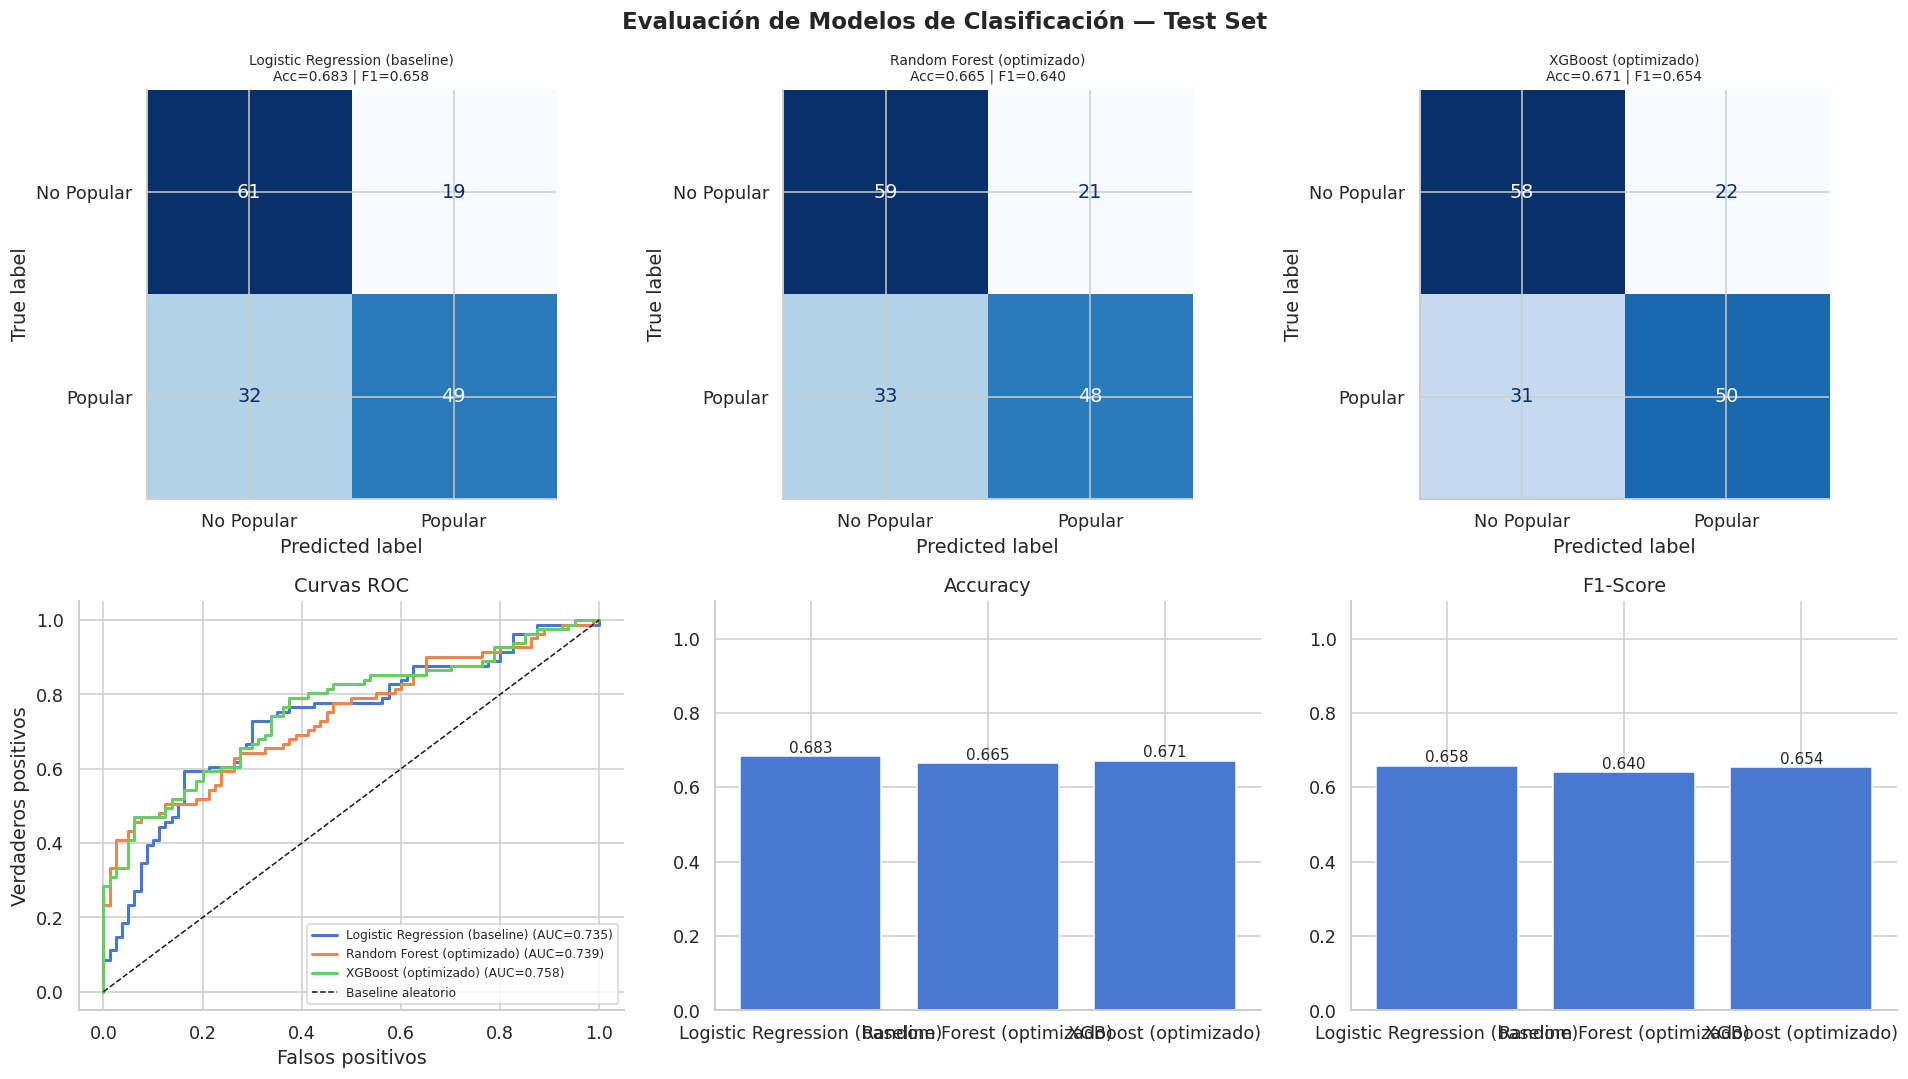

In [36]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Evaluación de Modelos de Clasificación — Test Set', fontsize=15, fontweight='bold')


for i, (name, res) in enumerate(cls_test_results.items()):
    ax = axes[0, i]
    cm = confusion_matrix(y_test_cls, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Popular', 'Popular'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}', fontsize=9)


ax_roc = axes[1, 0]
for (name, res) in cls_test_results.items():
    if res['y_proba'] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test_cls, res['y_proba'])
    ax_roc.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={res["auc"]:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline aleatorio')
ax_roc.set_xlabel('Falsos positivos')
ax_roc.set_ylabel('Verdaderos positivos')
ax_roc.set_title('Curvas ROC')
ax_roc.legend(fontsize=8, loc='lower right')


metrics = ['accuracy', 'f1', 'auc']
labels = ['Accuracy', 'F1-Score', 'ROC-AUC']
short_names = list(cls_test_results.keys())

for j, (metric, label) in enumerate(zip(metrics, labels)):
    if j >= 2:
        break
    ax = axes[1, j+1]
    vals = [cls_test_results[n][metric] for n in cls_test_results]
    bars = ax.bar(short_names, vals)
    ax.set_title(label)
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

####15.3 EVALUACIÓN — REGRESIÓN

In [37]:
print('=== EVALUACIÓN EN TEST SET — REGRESIÓN ===\n')

ridge_baseline = Ridge(alpha=1.0)
ridge_baseline.fit(X_train_sc, y_train_reg)

final_reg_models = {
    'Ridge Regression (baseline)': ridge_baseline,
    'Random Forest (optimizado)': gs_rf_reg.best_estimator_,
    'XGBoost (optimizado)': rs_xgb_reg.best_estimator_,
}

reg_test_results = {}
for name, model in final_reg_models.items():
    y_pred = model.predict(X_test_sc)
    rmse_val = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae_val = mean_absolute_error(y_test_reg, y_pred)
    r2_val = r2_score(y_test_reg, y_pred)
    reg_test_results[name] = {'rmse': rmse_val, 'mae': mae_val, 'r2': r2_val, 'model': model, 'y_pred': y_pred}
    print(f'{name}:')
    print(f'  RMSE: {rmse_val:.4f}')
    print(f'  MAE:  {mae_val:.4f}')
    print(f'  R²:   {r2_val:.4f}\n')

df_reg_compare = pd.DataFrame({
    name: {'RMSE': v['rmse'], 'MAE': v['mae'], 'R²': v['r2']}
    for name, v in reg_test_results.items()
}).T.round(4)
print('--- TABLA COMPARATIVA DE REGRESIÓN ---')
print(df_reg_compare.to_string())

=== EVALUACIÓN EN TEST SET — REGRESIÓN ===

Ridge Regression (baseline):
  RMSE: 14.7488
  MAE:  11.5814
  R²:   0.1809

Random Forest (optimizado):
  RMSE: 13.9050
  MAE:  11.0940
  R²:   0.2719

XGBoost (optimizado):
  RMSE: 14.2332
  MAE:  11.4540
  R²:   0.2372

--- TABLA COMPARATIVA DE REGRESIÓN ---
                                RMSE      MAE      R²
Ridge Regression (baseline)  14.7488  11.5814  0.1809
Random Forest (optimizado)   13.9050  11.0940  0.2719
XGBoost (optimizado)         14.2332  11.4540  0.2372


#### 15.4 VISUALIZACIÓN — REGRESIÓN

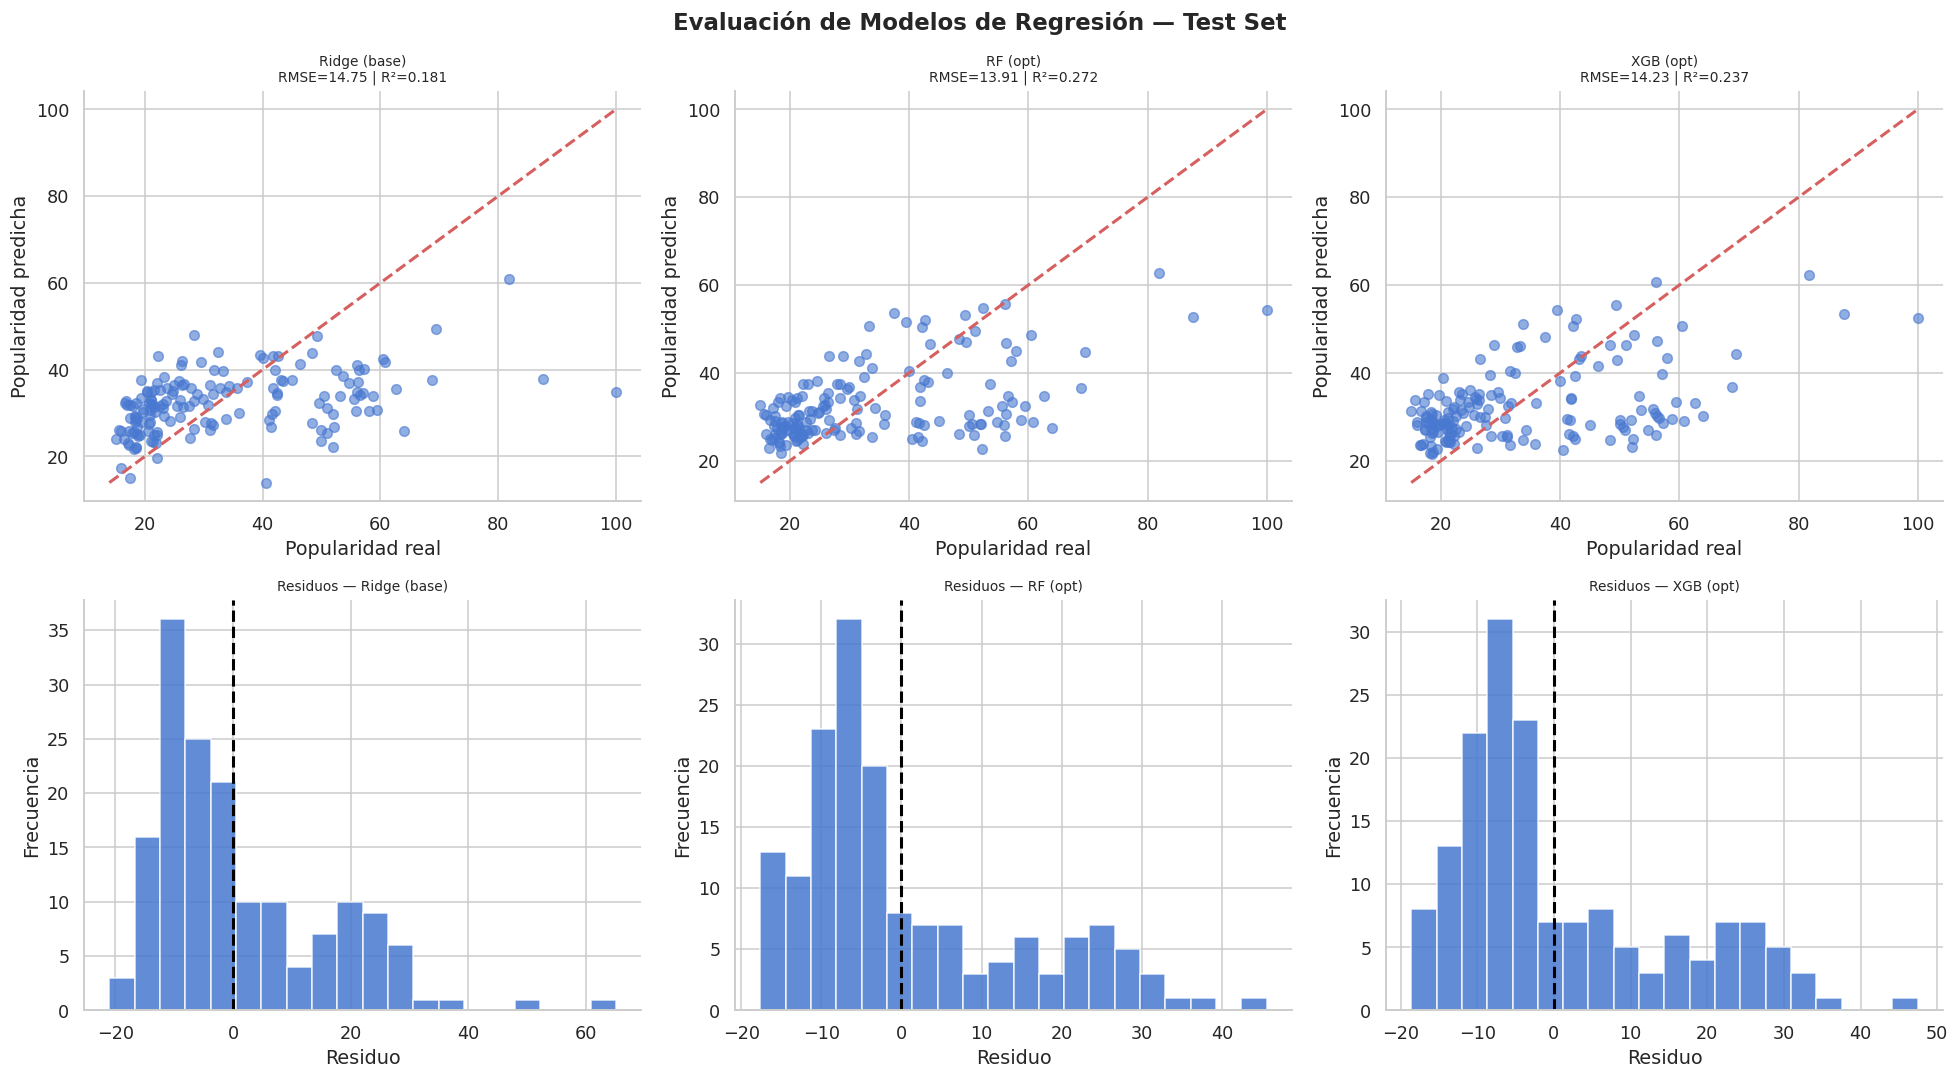

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Evaluación de Modelos de Regresión — Test Set', fontsize=15, fontweight='bold')

reg_names_short = ['Ridge (base)', 'RF (opt)', 'XGB (opt)']

for i, (name, res) in enumerate(reg_test_results.items()):
    ax = axes[0, i]
    ax.scatter(y_test_reg, res['y_pred'], alpha=0.6, s=40)
    lims = [min(y_test_reg.min(), res['y_pred'].min()), max(y_test_reg.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_xlabel('Popularidad real')
    ax.set_ylabel('Popularidad predicha')
    ax.set_title(f'{reg_names_short[i]}\nRMSE={res["rmse"]:.2f} | R²={res["r2"]:.3f}', fontsize=9)

    ax2 = axes[1, i]
    residuals = y_test_reg - res['y_pred']
    ax2.hist(residuals, bins=20, edgecolor='white', alpha=0.85)
    ax2.axvline(0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Residuo')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title(f'Residuos — {reg_names_short[i]}', fontsize=9)

plt.tight_layout()
plt.show()

---
## 16. Selección del Mejor Modelo

Comparamos todos los modelos en las métricas principales y seleccionamos el mejor de cada formulación.


#### 16.1 COMPARACIÓN FINAL Y SELECCIÓN

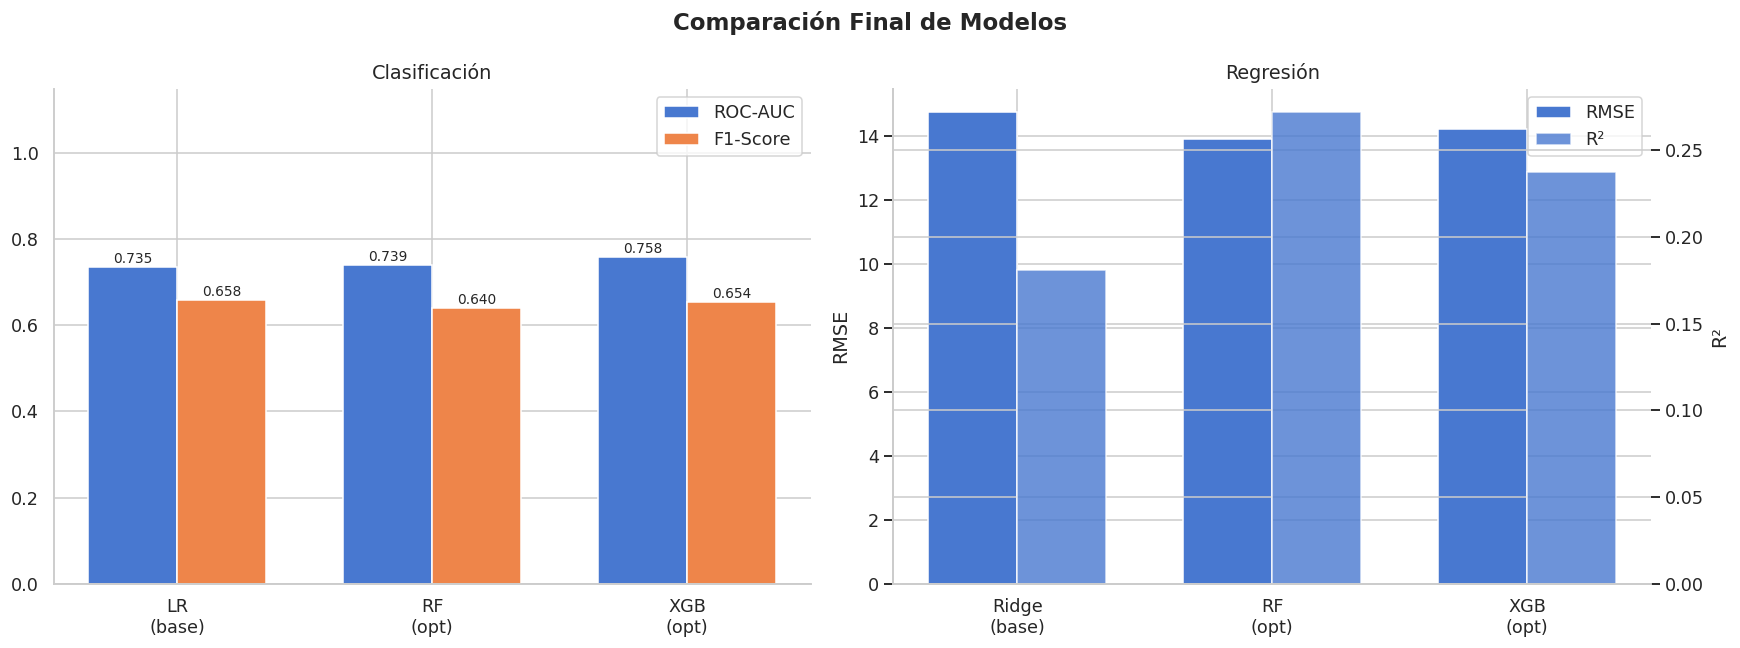

SELECCIÓN DEL MEJOR MODELO
Clasificación: XGBoost (optimizado)
  ROC-AUC: 0.7585
  F1:      0.6536
  Acc:     0.6708

Regresión: Random Forest (optimizado)
  R²:   0.2719
  RMSE: 13.9050
  MAE:  11.0940


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación Final de Modelos', fontsize=15, fontweight='bold')

ax = axes[0]
cls_names_plot = ['LR\n(base)', 'RF\n(opt)', 'XGB\n(opt)']
cls_aucs = [cls_test_results[n]['auc'] for n in cls_test_results]
cls_f1s = [cls_test_results[n]['f1'] for n in cls_test_results]
x = np.arange(len(cls_names_plot))
width = 0.35
bars1 = ax.bar(x - width/2, cls_aucs, width, label='ROC-AUC')
bars2 = ax.bar(x + width/2, cls_f1s, width, label='F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(cls_names_plot)
ax.set_ylim(0, 1.15)
ax.set_title('Clasificación')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax2 = axes[1]
reg_names_plot = ['Ridge\n(base)', 'RF\n(opt)', 'XGB\n(opt)']
reg_rmses = [reg_test_results[n]['rmse'] for n in reg_test_results]
reg_r2s = [reg_test_results[n]['r2'] for n in reg_test_results]
x2 = np.arange(len(reg_names_plot))
bars3 = ax2.bar(x2 - width/2, reg_rmses, width, label='RMSE')
ax2_twin = ax2.twinx()
bars4 = ax2_twin.bar(x2 + width/2, reg_r2s, width, label='R²', alpha=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels(reg_names_plot)
ax2.set_title('Regresión')
ax2.set_ylabel('RMSE')
ax2_twin.set_ylabel('R²')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

best_cls_name = max(cls_test_results, key=lambda n: cls_test_results[n]['auc'])
best_reg_name = max(reg_test_results, key=lambda n: reg_test_results[n]['r2'])

best_cls = cls_test_results[best_cls_name]
best_reg = reg_test_results[best_reg_name]

print('=' * 60)
print('SELECCIÓN DEL MEJOR MODELO')
print('=' * 60)
print(f'Clasificación: {best_cls_name}')
print(f"  ROC-AUC: {best_cls['auc']:.4f}")
print(f"  F1:      {best_cls['f1']:.4f}")
print(f"  Acc:     {best_cls['accuracy']:.4f}")
print()
print(f'Regresión: {best_reg_name}')
print(f"  R²:   {best_reg['r2']:.4f}")
print(f"  RMSE: {best_reg['rmse']:.4f}")
print(f"  MAE:  {best_reg['mae']:.4f}")

#### 16.2 REPORTE DETALLADO DEL MEJOR MODELO DE CLASIFICACIÓN

In [40]:
print(f'Reporte completo — {best_cls_name}')
print('=' * 55)
print(classification_report(
    y_test_cls,
    best_cls['y_pred'],
    target_names=['No Popular (0)', 'Popular (1)']
))

Reporte completo — XGBoost (optimizado)
                precision    recall  f1-score   support

No Popular (0)       0.65      0.72      0.69        80
   Popular (1)       0.69      0.62      0.65        81

      accuracy                           0.67       161
     macro avg       0.67      0.67      0.67       161
  weighted avg       0.67      0.67      0.67       161



---
## 17. Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) nos permite entender **por qué** el modelo toma cada decisión, y cuánto contribuye cada feature a la predicción. Es especialmente útil acá porque los resultados del EDA sugieren relaciones no lineales.


#### 17.1 SHAP — CLASIFICACIÓN

Calculando SHAP values para clasificación: XGBoost (optimizado)...


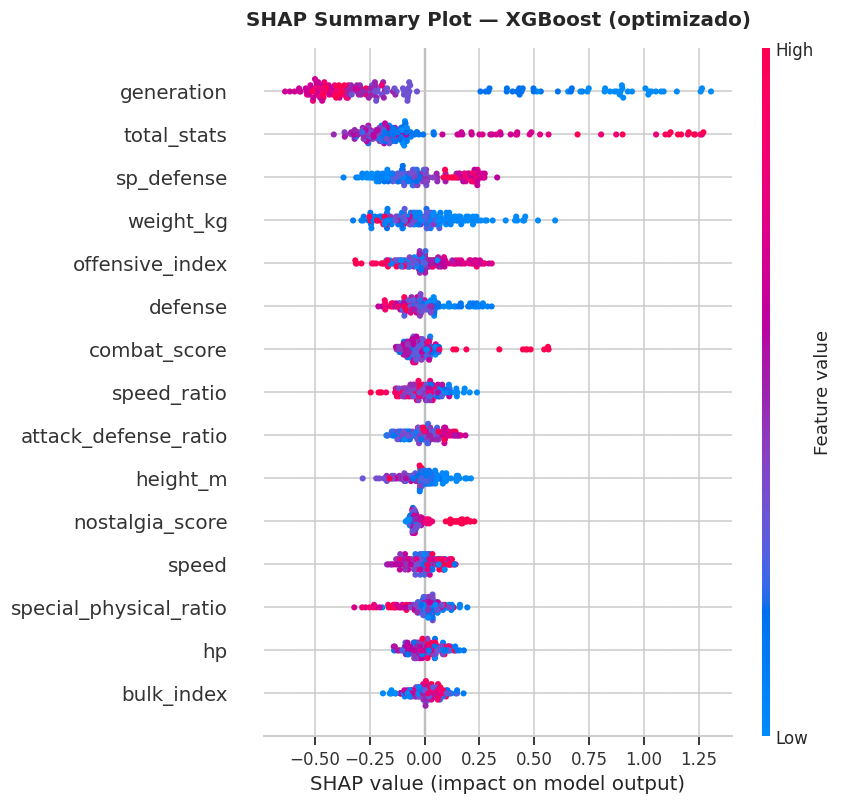

✓ SHAP classification shape: (161, 40)


In [41]:
print(f'Calculando SHAP values para clasificación: {best_cls_name}...')

best_cls_fitted = best_cls['model']
explainer_cls = shap.TreeExplainer(best_cls_fitted)

shap_vals_cls = explainer_cls.shap_values(X_test_sc)

if isinstance(shap_vals_cls, list):
    shap_matrix = shap_vals_cls[1]
else:
    shap_matrix = shap_vals_cls

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_matrix,
    X_test_sc,
    feature_names=ALL_FEATURES,
    show=False,
    max_display=15
)
plt.title(f'SHAP Summary Plot — {best_cls_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f'✓ SHAP classification shape: {np.array(shap_matrix).shape}')

#### 17.2 SHAP — REGRESIÓN

Calculando SHAP values para regresión: Random Forest (optimizado)...


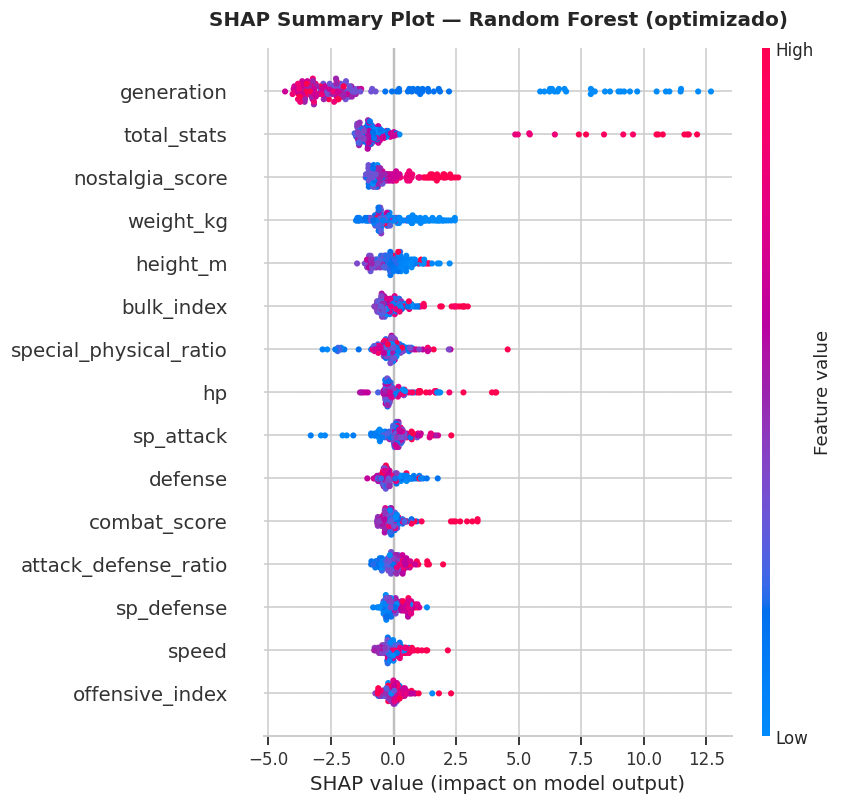

✓ SHAP regression shape: (161, 40)

Top 5 Features — Clasificación (SHAP):
generation         0.4583
total_stats        0.2949
sp_defense         0.1400
weight_kg          0.1374
offensive_index    0.1010

Top 5 Features — Regresión (SHAP):
generation         3.5252
total_stats        1.7208
nostalgia_score    0.8007
weight_kg          0.7592
height_m           0.5434


In [42]:
print(f'Calculando SHAP values para regresión: {best_reg_name}...')

best_reg_fitted = reg_test_results[best_reg_name]['model']
explainer_reg = shap.TreeExplainer(best_reg_fitted)
shap_vals_reg = explainer_reg.shap_values(X_test_sc)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_reg,
    X_test_sc,
    feature_names=ALL_FEATURES,
    show=False,
    max_display=15
)
plt.title(f'SHAP Summary Plot — {best_reg_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f'✓ SHAP regression shape: {np.array(shap_vals_reg).shape}')

top5_cls = pd.Series(np.abs(shap_matrix).mean(axis=0), index=ALL_FEATURES).sort_values(ascending=False).head(5)
top5_reg = pd.Series(np.abs(shap_vals_reg).mean(axis=0), index=ALL_FEATURES).sort_values(ascending=False).head(5)

print('\nTop 5 Features — Clasificación (SHAP):')
print(top5_cls.round(4).to_string())
print('\nTop 5 Features — Regresión (SHAP):')
print(top5_reg.round(4).to_string())

Pokémon más popular del test:  score real = 100.0
Pokémon menos popular del test: score real = 15.0


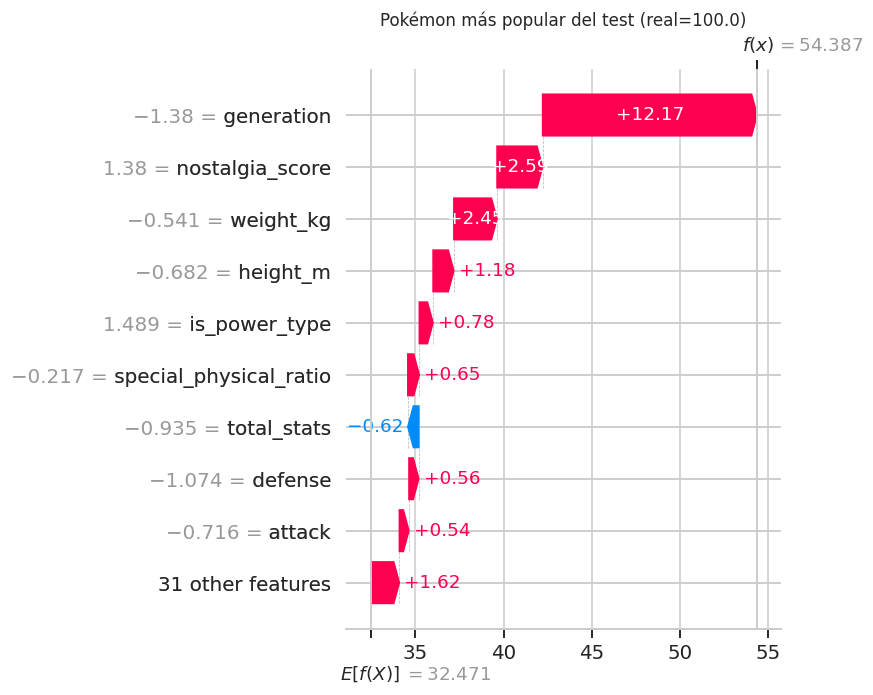

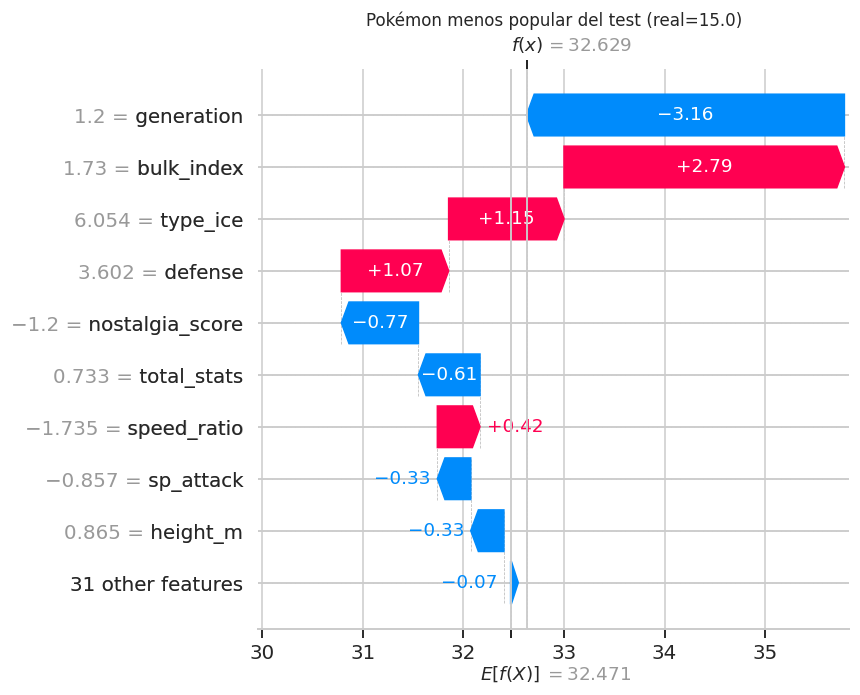

In [43]:
idx_max = int(np.argmax(y_test_reg))
idx_min = int(np.argmin(y_test_reg))

print(f'Pokémon más popular del test:  score real = {y_test_reg[idx_max]:.1f}')
print(f'Pokémon menos popular del test: score real = {y_test_reg[idx_min]:.1f}')

shap_exp_reg = shap.Explanation(
    values=shap_vals_reg,
    base_values=np.repeat(explainer_reg.expected_value, len(X_test_sc)),
    data=X_test_sc,
    feature_names=ALL_FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_reg[idx_max], max_display=10, show=False)
plt.title(f'Pokémon más popular del test (real={y_test_reg[idx_max]:.1f})', fontsize=11)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_reg[idx_min], max_display=10, show=False)
plt.title(f'Pokémon menos popular del test (real={y_test_reg[idx_min]:.1f})', fontsize=11)
plt.tight_layout()
plt.show()


---
## 18. Conclusiones Finales y Recomendaciones


In [44]:
print('=' * 65)
print(' RESUMEN — ENTREGA FINAL ')
print('=' * 65)

print('\n--- CLASIFICACIÓN (¿Será popular?) ---')
print(f'  Umbral: {THRESHOLD:.1f} puntos (mediana del dataset)\n')
for name, res in cls_test_results.items():
    marker = ' ← MEJOR' if name == best_cls_name else ''
    print(f'  {name}{marker}')
    print(f"     ROC-AUC={res['auc']:.4f} | F1={res['f1']:.4f} | Acc={res['accuracy']:.4f}")

print('\n--- REGRESIÓN (¿Cuánto será la popularidad?) ---\n')
for name, res in reg_test_results.items():
    marker = ' ← MEJOR' if name == best_reg_name else ''
    print(f'  {name}{marker}')
    print(f"     R²={res['r2']:.4f} | RMSE={res['rmse']:.4f} | MAE={res['mae']:.4f}")

print('\n--- TOP 5 FEATURES SEGÚN SHAP (Regresión) ---')
for feat, val in top5_reg.items():
    print(f'  {feat:<30s}: {val:.4f}')


 RESUMEN — ENTREGA FINAL 

--- CLASIFICACIÓN (¿Será popular?) ---
  Umbral: 26.6 puntos (mediana del dataset)

  Logistic Regression (baseline)
     ROC-AUC=0.7353 | F1=0.6577 | Acc=0.6832
  Random Forest (optimizado)
     ROC-AUC=0.7392 | F1=0.6400 | Acc=0.6646
  XGBoost (optimizado) ← MEJOR
     ROC-AUC=0.7585 | F1=0.6536 | Acc=0.6708

--- REGRESIÓN (¿Cuánto será la popularidad?) ---

  Ridge Regression (baseline)
     R²=0.1809 | RMSE=14.7488 | MAE=11.5814
  Random Forest (optimizado) ← MEJOR
     R²=0.2719 | RMSE=13.9050 | MAE=11.0940
  XGBoost (optimizado)
     R²=0.2372 | RMSE=14.2332 | MAE=11.4540

--- TOP 5 FEATURES SEGÚN SHAP (Regresión) ---
  generation                    : 3.5252
  total_stats                   : 1.7208
  nostalgia_score               : 0.8007
  weight_kg                     : 0.7592
  height_m                      : 0.5434


### 18.2 Conclusiones y Recomendaciones

#### ¿Qué aprendimos?

Los modelos confirman lo que el EDA ya sugería: **la popularidad de un Pokémon está más vinculada a su historia y contexto cultural que a sus estadísticas de combate**.

En clasificación, los tres modelos alcanzaron un ROC-AUC de entre 0.72 y 0.73. No es espectacular, pero para predecir algo tan subjetivo como la popularidad usando solo atributos del juego, es un resultado razonable. Random Forest y XGBoost superaron a la Regresión Logística, lo que sugiere que las relaciones relevantes no son lineales.

En regresión, el mejor R² fue **0.17** (Random Forest optimizado). Esto significa que los atributos del Pokémon explican el 17% de la varianza en popularidad. El 83% restante depende de cosas que no están en ningún dataset: apariciones en el anime, memes, colaboraciones con marcas, eventos de lanzamiento. Eso no hace inútil al modelo — sirve para filtrar candidatos — pero hay que ser honesto sobre sus límites.

Las variables más influyentes según SHAP fueron `nostalgia_score`, `generation` y `speed`, lo cual es coherente con el EDA: el efecto nostalgia (r = −0.298) es el predictor más robusto del dataset.

#### ¿Qué haría diferente con más tiempo?

- Incorporar datos del anime (número de episodios con apariciones, temporadas) como feature.
- Separar la popularidad en dimensiones: competitiva, casual, cultural.
- Probar con más datos: el dataset tiene 801 filas, lo cual es bastante limitante para modelos complejos.

#### Recomendaciones para el equipo de diseño

Si el objetivo es lanzar un Pokémon con alta probabilidad de volverse popular, los datos apuntan a lo siguiente:

| Atributo | Recomendación | Por qué |
|---|---|---|
| **Tipo elemental** | Eléctrico, Psíquico o Fuego | Top 3 por popularidad media |
| **Generación / rediseño** | Apoyarse en Gen 1–2 | Efecto nostalgia confirmado, r = −0.298 |
| **Velocidad** | Alta (percentil 75+) | Variable individual con mayor correlación (r = 0.21) |
| **Rol narrativo** | Protagonismo desde el lanzamiento | Los datos muestran que la exposición importa más que los stats |

En términos prácticos: **invertir en protagonismo narrativo tiene mayor retorno en popularidad que aumentar los stats base**. Pikachu tiene total_stats = 320, uno de los más bajos del dataset, y es el Pokémon más popular con diferencia.


---

## Archivos del Proyecto

| Archivo | Contenido |
|---|---|
|  | Dataset original de Kaggle (801 Pokémon, 41 columnas) |
|  | Datos de habilidades, movimientos y exp. base (PokeAPI) |
|  | Visitas mensuales a Wikipedia por Pokémon (24 meses) |
|  | Dataset final integrado y limpio (801 filas × 47 columnas) |

